In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Process all experiments

In [2]:
def compute_global_metrics(entropy, window=10):
    """Compute global metrics for entropy sequence."""
    # Basic statistics
    mean_val = np.mean(entropy)
    median_val = np.median(entropy)
    std_val = np.std(entropy)
    
    # Compute deltas
    deltas = np.diff(entropy)
    abs_deltas = np.abs(deltas)
    
    # Spikes: tokens where both incoming and outgoing deltas are in top 5%
    threshold_95 = np.percentile(abs_deltas, 95)
    num_spikes = 0
    for i in range(1, len(entropy) - 1):
        delta_prev = abs(entropy[i] - entropy[i-1])
        delta_next = abs(entropy[i+1] - entropy[i])
        if delta_prev >= threshold_95 and delta_next >= threshold_95:
            num_spikes += 1
    
    # Phase shifts: detect significant changes in rolling mean/std
    rolling_mean = np.full(len(entropy), np.nan)
    rolling_std = np.full(len(entropy), np.nan)
    for i in range(window, len(entropy)):
        rolling_mean[i] = np.mean(entropy[i-window:i])
        rolling_std[i] = np.std(entropy[i-window:i])
    
    # Detect phase shifts: large changes in rolling statistics
    mean_changes = np.abs(np.diff(rolling_mean[window:]))
    std_changes = np.abs(np.diff(rolling_std[window:]))
    
    mean_change_threshold = np.percentile(mean_changes[~np.isnan(mean_changes)], 90) if len(mean_changes) > 0 else 0
    std_change_threshold = np.percentile(std_changes[~np.isnan(std_changes)], 90) if len(std_changes) > 0 else 0
    
    phase_shifts = 0
    for i in range(len(mean_changes)):
        if (not np.isnan(mean_changes[i]) and mean_changes[i] >= mean_change_threshold) or \
           (not np.isnan(std_changes[i]) and std_changes[i] >= std_change_threshold):
            phase_shifts += 1
    
    return {
        'mean': mean_val,
        'median': median_val,
        'std': std_val,
        'num_spikes': num_spikes,
        'phase_shifts': phase_shifts
    }

In [3]:
# Load all experiments
experiments = {
    'aim_1_20251113_025853': 'experiments/aim_1_20251113_025853/experiment.json',
    'aim_1c_20251113_025929': 'experiments/aim_1c_20251113_025929/experiment.json',
    'aim_2_20251113_130200': 'experiments/aim_2_20251113_130200/experiment.json',
    'aim_2c_20251113_072608': 'experiments/aim_2c_20251113_072608/experiment.json',
    'aim_3_20251113_025935': 'experiments/aim_3_20251113_025935/experiment.json',
    'aim_3c_20251113_081324': 'experiments/aim_3c_20251113_081324/experiment.json',
}

def extract_all_rollouts(experiments):
    """Extract all rollouts with their metrics."""
    all_rollouts = []
    
    for exp_name, exp_path in experiments.items():
        with open(exp_path) as f:
            data = json.load(f)

        condition = 'conditioned' if 'c' in exp_name else 'not_conditioned'
        
        for problem_key, problem_data in data['results'].items():
            problem_idx = problem_data['dataset_index']
            
            for rollout in problem_data['rollouts']:
                # Initialize placeholder for entropy sequence
                entropy_seq = []
                
                # Load the corresponding graph_structure.json
                with open(f'experiments/{exp_name}/problem_{problem_idx}/rollout_{rollout['rollout_idx']}/graph_structure.json', 'r') as f:
                    graph_structure = json.load(f)
                entropy_seq = np.array([item['metric_value'] for item in graph_structure['final_sequence']])
                
                if len(entropy_seq) == 0:
                    continue
                
                # Compute metrics using your existing functions
                global_metrics = compute_global_metrics(np.array(entropy_seq))
                
                all_rollouts.append({
                    'experiment': exp_name,
                    'condition': condition,
                    'problem_idx': problem_idx,
                    'rollout_idx': rollout['rollout_idx'],
                    'is_correct': rollout['is_correct'],
                    'num_tokens': rollout['num_tokens'],
                    'mean_entropy': global_metrics['mean'],
                    'median_entropy': global_metrics['median'],
                    'std_entropy': global_metrics['std'],
                    'num_spikes': global_metrics['num_spikes'],
                    'phase_shifts': global_metrics['phase_shifts'],
                    'max_entropy': np.max(entropy_seq),
                    'late_stage_mean': np.mean(entropy_seq[-int(0.2*len(entropy_seq)):]) if len(entropy_seq) > 5 else np.nan,
                    'cumulative_normalized': np.sum(entropy_seq) / len(entropy_seq)
                })
    
    return pd.DataFrame(all_rollouts)

df = extract_all_rollouts(experiments)

print(f"Total rollouts: {len(df)}")
print(f"Correct: {df['is_correct'].sum()}, Incorrect: {(~df['is_correct']).sum()}")

Total rollouts: 3000
Correct: 1471, Incorrect: 1529


In [4]:
nc_correct = len(df[(df['condition'] == 'not_conditioned') & (df['is_correct'])])
nc_total = len(df[(df['condition'] == 'not_conditioned')])

c_correct = len(df[(df['condition'] == 'conditioned') & (df['is_correct'])])
c_total = len(df[(df['condition'] == 'conditioned')])

display(pd.DataFrame([
    {'Condition': 'Not Conditioned', 'Correct': nc_correct, 'Total': nc_total, 'Accuracy (%)': 100 * nc_correct / nc_total},
    {'Condition': 'Conditioned', 'Correct': c_correct, 'Total': c_total, 'Accuracy (%)': 100 * c_correct / c_total},
]))

,Condition,Correct,Total,Accuracy (%)
0,Not Conditioned,124,1500,8.266667
1,Conditioned,1347,1500,89.800000


In [5]:
display(df.head())
display(df.tail())

,experiment,condition,problem_idx,rollout_idx,is_correct,num_tokens,mean_entropy,median_entropy,std_entropy,num_spikes,phase_shifts,max_entropy,late_stage_mean,cumulative_normalized
0,aim_1_20251113_025853,not_conditioned,0,0,True,1031,0.073540,0.000018,0.226627,20,137,1.859375,0.067520,0.073540
1,aim_1_20251113_025853,not_conditioned,0,1,False,1139,0.098681,0.000126,0.250649,21,154,1.835938,0.098725,0.098681
2,aim_1_20251113_025853,not_conditioned,0,2,False,1220,0.083792,0.000028,0.234245,24,160,2.140625,0.129111,0.083792
3,aim_1_20251113_025853,not_conditioned,0,3,True,1071,0.066520,0.000021,0.202809,22,141,1.445312,0.069744,0.066520
4,aim_1_20251113_025853,not_conditioned,0,4,False,1584,0.095532,0.000062,0.262420,30,215,1.898438,0.160986,0.095532


,experiment,condition,problem_idx,rollout_idx,is_correct,num_tokens,mean_entropy,median_entropy,std_entropy,num_spikes,phase_shifts,max_entropy,late_stage_mean,cumulative_normalized
2995,aim_3c_20251113_081324,conditioned,29,45,True,407,0.498726,0.271484,0.578809,6,66,2.781250,0.356544,0.498726
2996,aim_3c_20251113_081324,conditioned,29,46,True,714,0.378202,0.081299,0.517246,8,106,2.281250,0.279604,0.378202
2997,aim_3c_20251113_081324,conditioned,29,47,True,834,0.225783,0.000814,0.428514,12,122,2.484375,0.394514,0.225783
2998,aim_3c_20251113_081324,conditioned,29,48,True,728,0.388166,0.081787,0.554370,12,104,3.593750,0.171037,0.388166
2999,aim_3c_20251113_081324,conditioned,29,49,True,1051,0.316953,0.037842,0.486683,17,148,3.000000,0.260108,0.316953


# 4-Panel Comparison for Token-level Analysis (across rollouts)

## Plotting

In [ ]:
def compute_per_step_metrics(entropy, window=10):
    """Compute per-step metrics for entropy sequence."""
    n = len(entropy)
    
    # Cumulative sum
    cumsum = np.cumsum(entropy)
    
    # Rolling volatility (std)
    volatility = np.full(n, np.nan)
    for i in range(window, n):
        volatility[i] = np.std(entropy[i-window:i])
    
    # Rolling slope
    slope = np.full(n, np.nan)
    for i in range(window, n):
        slope[i] = np.polyfit(range(window), entropy[i-window:i], 1)[0]
    
    return {
        'cumsum': cumsum,
        'volatility': volatility,
        'slope': slope
    }

In [ ]:
def plot_entropy_4panel(df, exp_names, problem_idx=None, wspace=0.15, hspace=0.15):
    """
    Create 4-panel entropy visualization.
    
    Parameters:
    - df: Full dataframe with all rollouts
    - exp_names: List of experiment names to include
    - problem_idx: Single problem number, or None for all problems
    - wspace, hspace: Spacing between panels
    """
    # Filter rollouts
    if problem_idx is not None:
        filtered_df = df[(df['experiment'].isin(exp_names)) & (df['problem_idx'] == problem_idx)]
    else:
        filtered_df = df[df['experiment'].isin(exp_names)]
    
    # Filter into 4 groups
    groups = {
        'Correct, Conditioned': filtered_df[(filtered_df['condition'] == 'conditioned') & (filtered_df['is_correct'])],
        'Incorrect, Conditioned': filtered_df[(filtered_df['condition'] == 'conditioned') & (~filtered_df['is_correct'])],
        'Correct, Not Conditioned': filtered_df[(filtered_df['condition'] == 'not_conditioned') & (filtered_df['is_correct'])],
        'Incorrect, Not Conditioned': filtered_df[(filtered_df['condition'] == 'not_conditioned') & (~filtered_df['is_correct'])]
    }
    
    # Load entropy sequences for each group
    group_sequences = {}
    for group_name, group_df in groups.items():
        sequences = []
        for _, row in group_df.iterrows():
            exp_name_i = row['experiment']
            problem_idx_i = row['problem_idx']
            rollout_idx_i = row['rollout_idx']
            
            try:
                with open(f'experiments/{exp_name_i}/problem_{problem_idx_i}/rollout_{rollout_idx_i}/graph_structure.json', 'r') as f:
                    graph_structure = json.load(f)
                entropy_seq = np.array([item['metric_value'] for item in graph_structure['final_sequence']])
                if len(entropy_seq) > 0:
                    sequences.append(entropy_seq)
            except FileNotFoundError:
                continue
        
        group_sequences[group_name] = sequences
    
    # Compute mean and std at each token position
    def compute_stats(sequences):
        max_len = max(len(seq) for seq in sequences)
        means = []
        stds = []
        
        for pos in range(max_len):
            values = [seq[pos] for seq in sequences if len(seq) > pos]
            if len(values) > 0:
                means.append(np.mean(values))
                stds.append(np.std(values))
            else:
                means.append(np.nan)
                stds.append(np.nan)
        
        return np.array(means), np.array(stds)
    
    group_stats = {}
    for group_name, sequences in group_sequences.items():
        means, stds = compute_stats(sequences)
        group_stats[group_name] = {'means': means, 'stds': stds}
    
    # Create 4-panel plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True, sharey=True,
                             gridspec_kw={'wspace': wspace, 'hspace': hspace})
    axes = axes.flatten()
    
    group_order = [
        'Correct, Conditioned',
        'Correct, Not Conditioned',
        'Incorrect, Conditioned',
        'Incorrect, Not Conditioned'
    ]
    
    for idx, group_name in enumerate(group_order):
        ax = axes[idx]
        stats = group_stats[group_name]
        means = stats['means']
        stds = stats['stds']
        positions = np.arange(len(means))
        
        # Plot mean line
        ax.plot(positions, means, linewidth=2, label='Mean')
        
        # Plot std band
        ax.fill_between(positions, means - stds, means + stds, alpha=0.3, label='±1 std')
        
        # Add title with count inside panel
        title_text = f"{group_name} (n={len(group_sequences[group_name])})"
        ax.text(0.05, 0.95, title_text, transform=ax.transAxes, 
                fontsize=11, fontweight='bold', va='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)

        # Zoom into trajectory
        # Set y-axis to focus on the 0-0.5 range where the differences are
        ax.set_ylim(-0.3, 0.7)
        # Cut x-axis at position 1500 (outlier zone)
        ax.set_xlim(0, 1500)
        
        # Configure spines and ticks
        if idx == 0:
            ax.spines['top'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.spines['bottom'].set_visible(True)
            ax.spines['right'].set_visible(True)
            ax.xaxis.set_ticks_position('bottom')
            ax.yaxis.set_ticks_position('right')
            ax.tick_params(labelbottom=True, labelright=True)
        elif idx == 1:
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(True)
            ax.spines['left'].set_visible(False)
            ax.xaxis.set_ticks_position('bottom')
            ax.tick_params(labelbottom=True, labelleft=False, labelright=False, 
                          left=False, right=False)
        elif idx == 2:
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(True)
            ax.yaxis.set_ticks_position('right')
            ax.tick_params(labelbottom=False, labeltop=False, labelright=True, labelleft=False,
                          bottom=False, top=False, left=False)
        else:
            ax.spines['bottom'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['top'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.tick_params(labelbottom=False, labeltop=False, labelleft=False, labelright=False, 
                          bottom=False, top=False, left=False, right=False)
    
    # Add axis labels
    fig.text(0.5, 0.08, 'Token Position', ha='center', fontsize=12)
    fig.text(0.08, 0.5, 'Entropy', va='center', rotation='vertical', fontsize=12)
    
    plt.show()

    return groups, group_sequences, group_stats

## For all rollouts for a single problem (Problem 0)

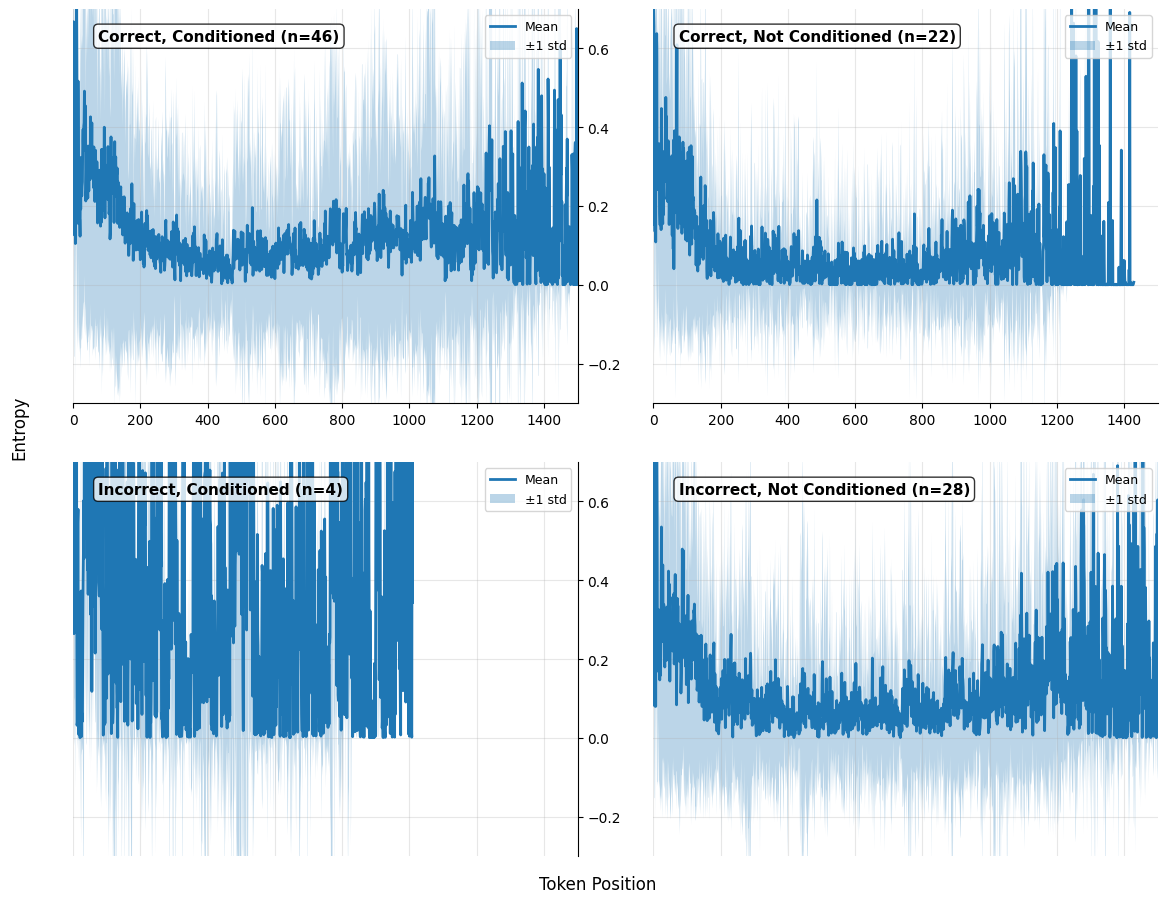

In [ ]:
# Analyze single problem (problem 0) from aim_1 and aim_1c
groups, group_sequences, group_stats = plot_entropy_4panel(
    df=df,
    exp_names=["aim_1_20251113_025853", "aim_1c_20251113_025929"],
    problem_idx=0
)

## For all rollouts for all problems

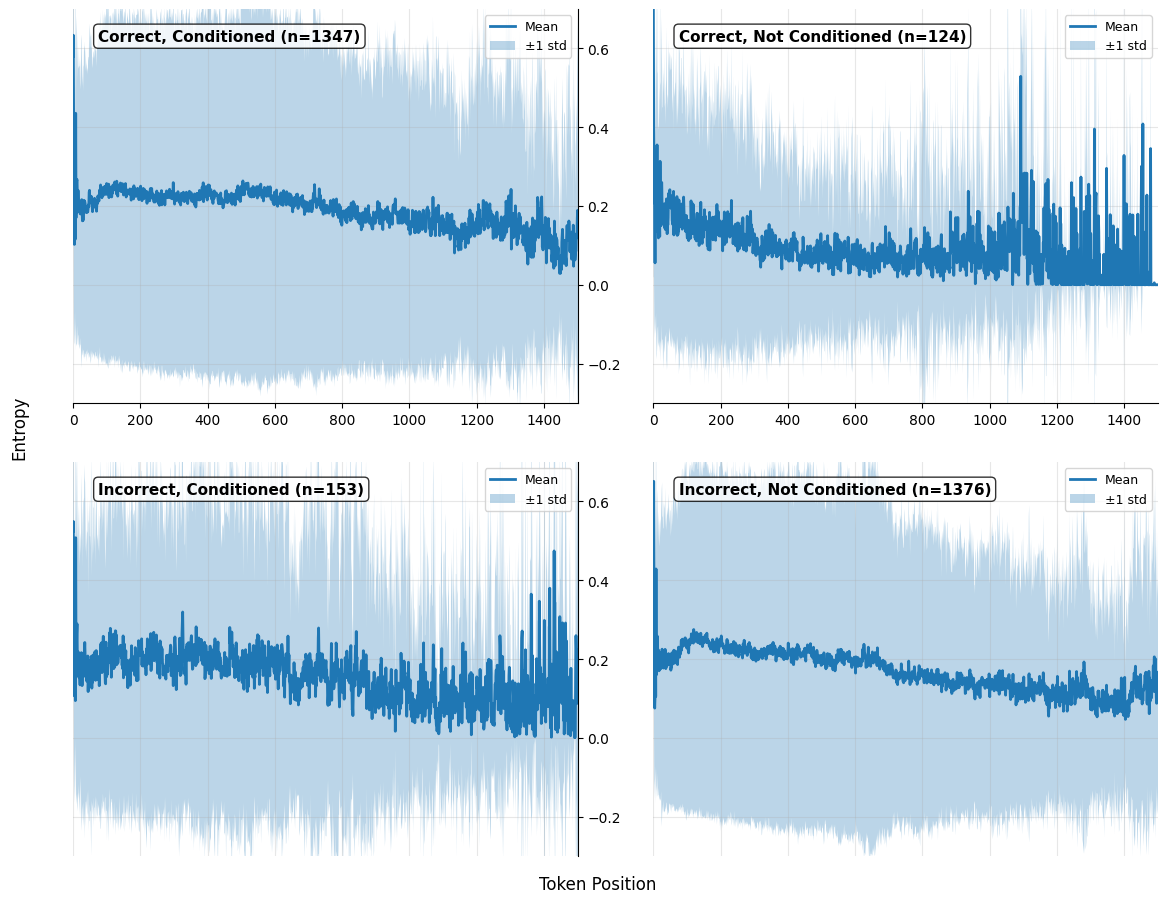

In [ ]:
# Analyze across all problems in all experiments
all_experiments = [
    'aim_1_20251113_025853',
    'aim_1c_20251113_025929',
    'aim_2_20251113_130200',
    'aim_2c_20251113_072608',
    'aim_3_20251113_025935',
    'aim_3c_20251113_081324'
]

groups, group_sequences, group_stats = plot_entropy_4panel(
    df=df,
    exp_names=all_experiments,
    problem_idx=None  # None means all problems
)

### Could length distributions be affecting the trends?

In [ ]:
# Check length distributions
for group_name, group_df in groups.items():
    lengths = group_df['num_tokens'].values
    print(f"\n{group_name} (n={len(group_df)}):")
    print(f"  Median: {np.median(lengths):.0f}")
    print(f"  75th percentile: {np.percentile(lengths, 75):.0f}")
    print(f"  95th percentile: {np.percentile(lengths, 95):.0f}")
    print(f"  Max: {np.max(lengths):.0f}")
    print(f"  Rollouts >2000 tokens: {(lengths > 2000).sum()} ({100*(lengths > 2000).sum()/len(lengths):.1f}%)")


Correct, Conditioned (n=1347):
  Median: 832
  75th percentile: 1044
  95th percentile: 1431
  Max: 2747
  Rollouts >2000 tokens: 12 (0.9%)

Incorrect, Conditioned (n=153):
  Median: 826
  75th percentile: 1056
  95th percentile: 1630
  Max: 2613
  Rollouts >2000 tokens: 5 (3.3%)

Correct, Not Conditioned (n=124):
  Median: 740
  75th percentile: 973
  95th percentile: 1228
  Max: 2010
  Rollouts >2000 tokens: 1 (0.8%)

Incorrect, Not Conditioned (n=1376):
  Median: 794
  75th percentile: 1030
  95th percentile: 1513
  Max: 3537
  Rollouts >2000 tokens: 23 (1.7%)


# Global Metrics across Conditioned vs Non-Conditioned

## Non-Conditioned

In [ ]:
from scipy import stats

# Focus on non-conditioned data
df_nc = df[df['condition'] == 'not_conditioned']
correct_nc = df_nc[df_nc['is_correct']]
incorrect_nc = df_nc[~df_nc['is_correct']]

metrics = ['mean_entropy', 'max_entropy', 'std_entropy', 'late_stage_mean']

print("NON-CONDITIONED: Correct vs Incorrect")
print("="*60)
for metric in metrics:
    # Separate metric's values for correct vs incorrect rollouts
    c_vals = correct_nc[metric].dropna()
    i_vals = incorrect_nc[metric].dropna()
    
    # Wuelch's T-test (without assuming equal variances between C & I)
    t_stat, p_val = stats.ttest_ind(c_vals, i_vals, equal_var=False)
    
    # Cohen's d
    pooled_std = np.sqrt(((len(c_vals)-1)*c_vals.std()**2 + 
                          (len(i_vals)-1)*i_vals.std()**2) / 
                         (len(c_vals) + len(i_vals) - 2))
    cohens_d = (c_vals.mean() - i_vals.mean()) / pooled_std
    
    print(f"\n{metric}:")
    print(f"  Correct: μ={c_vals.mean():.4f}, σ={c_vals.std():.4f}")
    print(f"  Incorrect: μ={i_vals.mean():.4f}, σ={i_vals.std():.4f}")
    print(f"  Δ={c_vals.mean() - i_vals.mean():.4f}")
    print(f"  t={t_stat:.3f}, p={p_val:.6f}, d={cohens_d:.3f}")

NON-CONDITIONED: Correct vs Incorrect

mean_entropy:
  Correct: μ=0.1142, σ=0.0693
  Incorrect: μ=0.2216, σ=0.1503
  Δ=-0.1074
  t=-14.455, p=0.000000, d=-0.739

max_entropy:
  Correct: μ=1.8574, σ=0.3898
  Incorrect: μ=2.2948, σ=0.4426
  Δ=-0.4374
  t=-11.828, p=0.000000, d=-0.997

std_entropy:
  Correct: μ=0.2689, σ=0.0870
  Incorrect: μ=0.3931, σ=0.1417
  Δ=-0.1242
  t=-14.283, p=0.000000, d=-0.900

late_stage_mean:
  Correct: μ=0.0852, σ=0.0660
  Incorrect: μ=0.2046, σ=0.2400
  Δ=-0.1194
  t=-13.606, p=0.000000, d=-0.518


/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/70451902.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_correct, data_incorrect],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/70451902.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_correct, data_incorrect],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/70451902.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_correct, data_incorrect],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/70451902.py:12: MatplotlibDeprecati

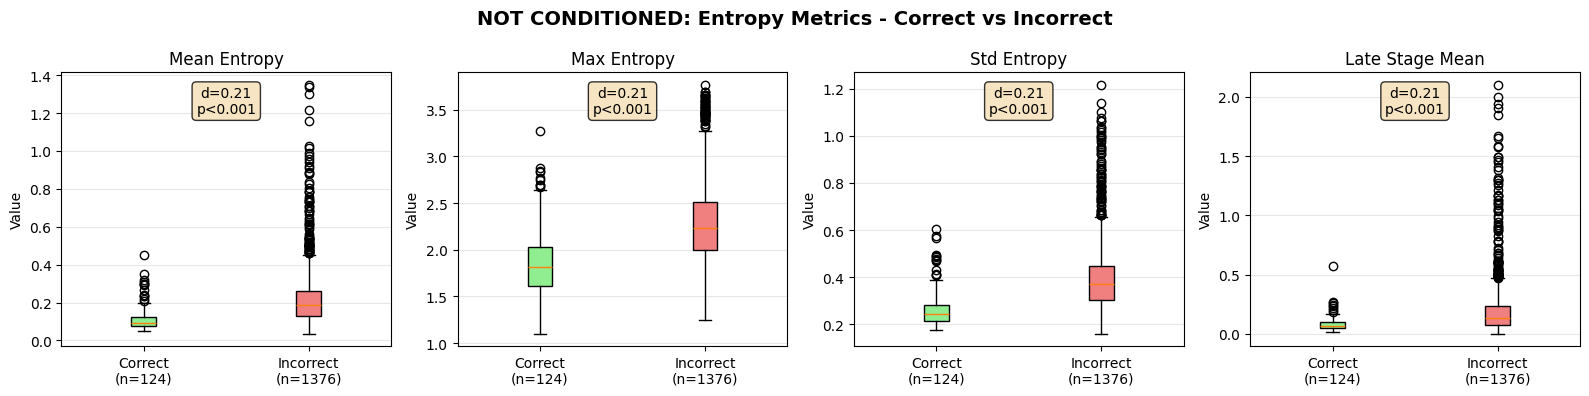

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics_plot = ['mean_entropy', 'max_entropy', 'std_entropy', 'late_stage_mean']

df_nc = df[df['condition'] == 'not_conditioned']

for idx, metric in enumerate(metrics_plot):
    ax = axes[idx]
    
    data_correct = df_nc[df_nc['is_correct']][metric].dropna()
    data_incorrect = df_nc[~df_nc['is_correct']][metric].dropna()
    
    bp = ax.boxplot([data_correct, data_incorrect], 
                     labels=['Correct\n(n=124)', 'Incorrect\n(n=1376)'],
                     patch_artist=True)
    
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    # Add Cohen's d annotation
    ax.text(0.5, 0.95, f"d={abs(cohens_d):.2f}\np<0.001", 
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.set_title(metric.replace('_', ' ').title())
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('NOT CONDITIONED: Entropy Metrics - Correct vs Incorrect', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Conditioned

In [ ]:
# CONDITIONED data
df_c = df[df['condition'] == 'conditioned']
correct_c = df_c[df_c['is_correct']]
incorrect_c = df_c[~df_c['is_correct']]

print("\n\nCONDITIONED: Correct vs Incorrect")
print("="*60)
for metric in metrics:
    c_vals = correct_c[metric].dropna()
    i_vals = incorrect_c[metric].dropna()
    
    t_stat, p_val = stats.ttest_ind(c_vals, i_vals, equal_var=False)
    
    pooled_std = np.sqrt(((len(c_vals)-1)*c_vals.std()**2 + 
                          (len(i_vals)-1)*i_vals.std()**2) / 
                         (len(c_vals) + len(i_vals) - 2))
    cohens_d = (c_vals.mean() - i_vals.mean()) / pooled_std
    
    print(f"\n{metric}:")
    print(f"  Correct: μ={c_vals.mean():.4f}, σ={c_vals.std():.4f}")
    print(f"  Incorrect: μ={i_vals.mean():.4f}, σ={i_vals.std():.4f}")
    print(f"  Δ={c_vals.mean() - i_vals.mean():.4f}")
    print(f"  t={t_stat:.3f}, p={p_val:.6f}, d={cohens_d:.3f}")



CONDITIONED: Correct vs Incorrect

mean_entropy:
  Correct: μ=0.2334, σ=0.1620
  Incorrect: μ=0.1990, σ=0.1303
  Δ=0.0343
  t=3.007, p=0.002965, d=0.216

max_entropy:
  Correct: μ=2.3524, σ=0.4702
  Incorrect: μ=2.2667, σ=0.4546
  Δ=0.0857
  t=2.201, p=0.028932, d=0.183

std_entropy:
  Correct: μ=0.4044, σ=0.1438
  Incorrect: μ=0.3738, σ=0.1445
  Δ=0.0306
  t=2.480, p=0.014023, d=0.212

late_stage_mean:
  Correct: μ=0.2777, σ=0.2452
  Incorrect: μ=0.2258, σ=0.2405
  Δ=0.0519
  t=2.525, p=0.012401, d=0.212


## Non-Conditioned vs Conditioned

/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/4044578037.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_correct, data_incorrect],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/4044578037.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_correct, data_incorrect],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/4044578037.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([data_correct, data_incorrect],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/4044578037.py:22: MatplotlibD

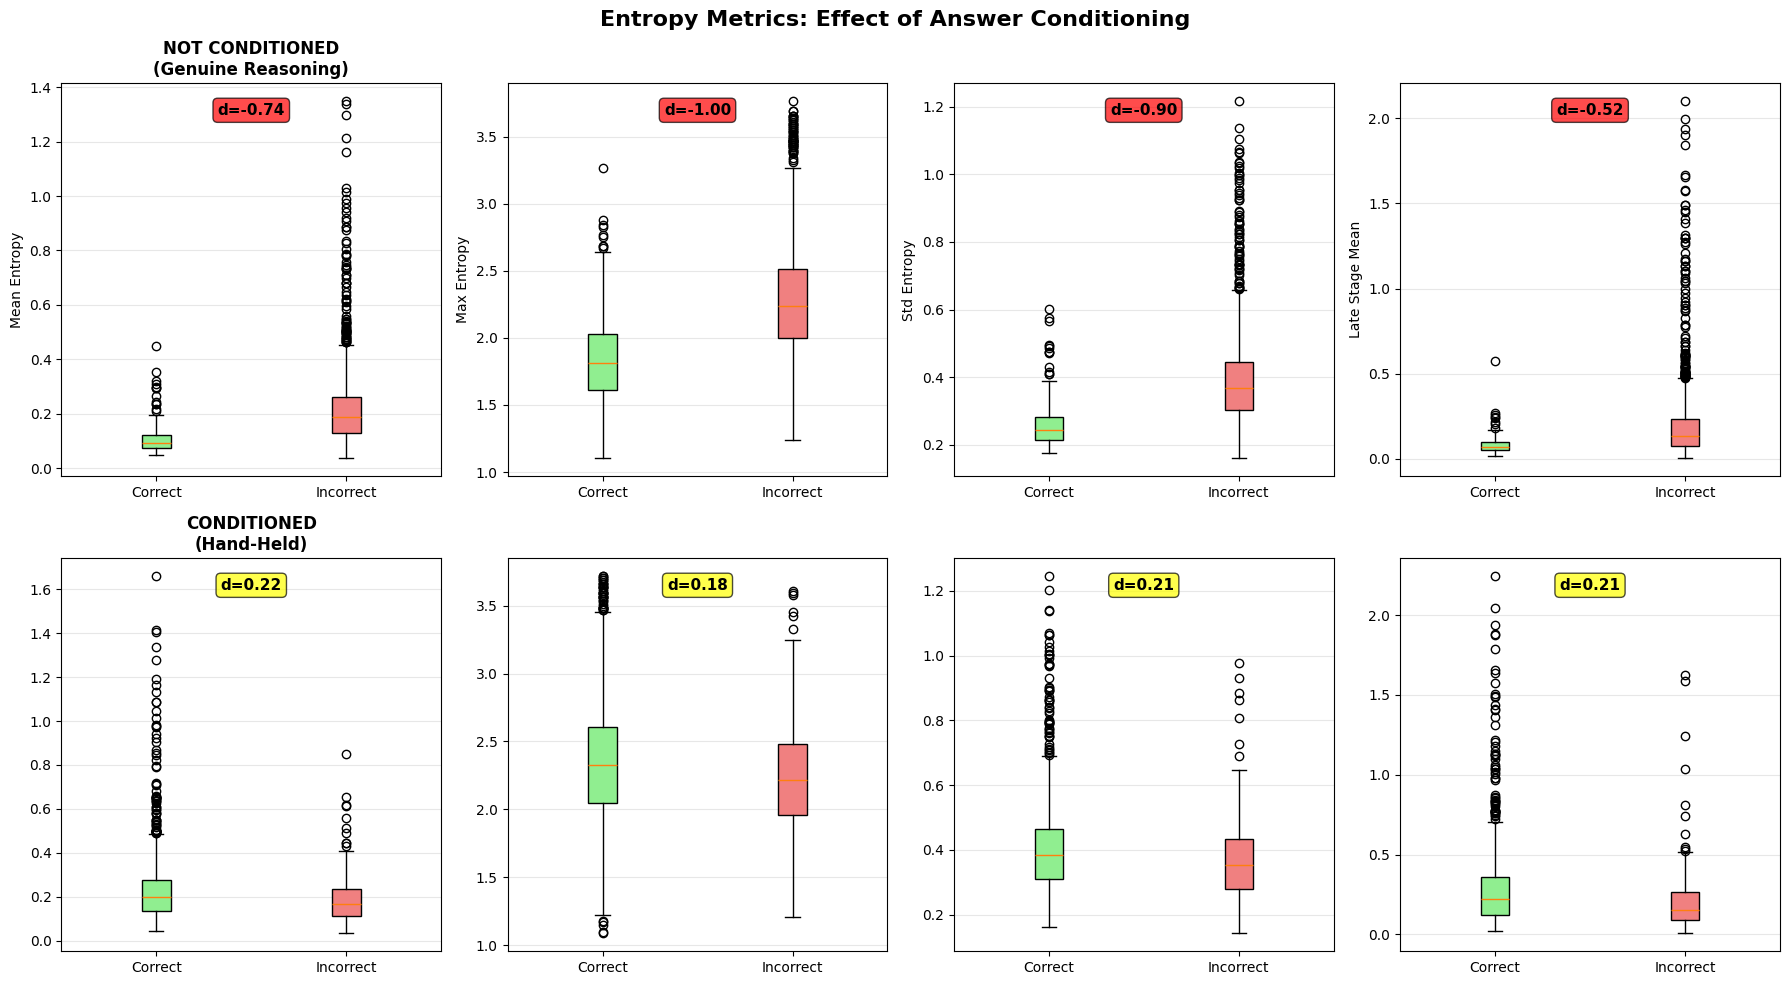

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

metrics = ['mean_entropy', 'max_entropy', 'std_entropy', 'late_stage_mean']
conditions = ['not_conditioned', 'conditioned']
titles = ['NOT CONDITIONED\n(Genuine Reasoning)', 'CONDITIONED\n(Hand-Held)']

for col_idx, condition in enumerate(conditions):
    df_cond = df[df['condition'] == condition]
    
    for row_idx, metric in enumerate(metrics):
        ax = axes[col_idx, row_idx]
        
        data_correct = df_cond[df_cond['is_correct']][metric].dropna()
        data_incorrect = df_cond[~df_cond['is_correct']][metric].dropna()
        
        # Compute effect size
        pooled_std = np.sqrt(((len(data_correct)-1)*data_correct.std()**2 + 
                              (len(data_incorrect)-1)*data_incorrect.std()**2) / 
                             (len(data_correct) + len(data_incorrect) - 2))
        cohens_d = (data_correct.mean() - data_incorrect.mean()) / pooled_std
        
        bp = ax.boxplot([data_correct, data_incorrect],
                        labels=['Correct', 'Incorrect'],
                        patch_artist=True)
        
        bp['boxes'][0].set_facecolor('lightgreen')
        bp['boxes'][1].set_facecolor('lightcoral')
        
        # Annotation with effect size
        ax.text(0.5, 0.95, f"d={cohens_d:.2f}", 
                transform=ax.transAxes, ha='center', va='top',
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', 
                         facecolor='red' if abs(cohens_d) > 0.5 else 'yellow',
                         alpha=0.7))
        
        if col_idx == 0:
            ax.set_ylabel(metric.replace('_', ' ').title())
        if row_idx == 0:
            ax.set_title(titles[col_idx], fontsize=12, fontweight='bold')
        
        ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Entropy Metrics: Effect of Answer Conditioning', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('conditioning_effect.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
df[(df['condition'] == 'conditioned') & (~df['is_correct'])].sample(5)

,experiment,condition,problem_idx,rollout_idx,is_correct,num_tokens,mean_entropy,median_entropy,std_entropy,num_spikes,phase_shifts,max_entropy,late_stage_mean,cumulative_normalized
1953,aim_2c_20251113_072608,conditioned,19,3,False,570,0.233998,0.002052,0.441691,9,85,2.578125,0.125121,0.233998
2845,aim_3c_20251113_081324,conditioned,26,45,False,2336,0.063060,0.000256,0.209126,48,290,1.921875,0.045827,0.063060
716,aim_1c_20251113_025929,conditioned,4,16,False,926,0.188805,0.002090,0.371489,15,125,2.375000,0.254053,0.188805
641,aim_1c_20251113_025929,conditioned,2,41,False,615,0.284867,0.007233,0.443582,7,86,2.109375,0.217471,0.284867
2678,aim_3c_20251113_081324,conditioned,23,28,False,350,0.228184,0.003662,0.429210,5,49,2.171875,0.215355,0.228184


# Entropy Trajectory over Generation

## Single Pass

Trajectories diverge at 0% of generation
Difference at divergence: 0.193


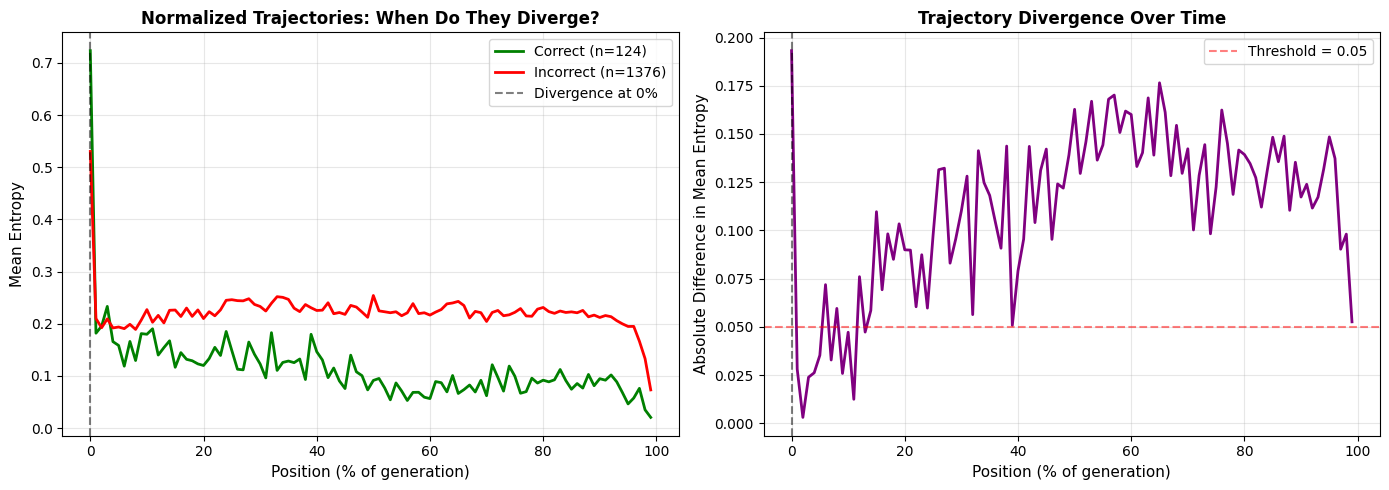


STATISTICAL ANALYSIS AT KEY POSITIONS

POSITION 0%
Correct: μ=0.7235, σ=0.3548
Incorrect: μ=0.5303, σ=0.3228
Difference: 0.1932
t=6.325, p=3.335109359545318e-10, d=0.593

POSITION 5%
Correct: μ=0.1584, σ=0.3162
Incorrect: μ=0.1938, σ=0.3303
Difference: -0.0353
t=-1.144, p=0.2527434853318889, d=-0.107

POSITION 20%
Correct: μ=0.1200, σ=0.2526
Incorrect: μ=0.2100, σ=0.3582
Difference: -0.0900
t=-2.734, p=0.0063211651199756485, d=-0.257

POSITION 50%
Correct: μ=0.0914, σ=0.2107
Incorrect: μ=0.2541, σ=0.4459
Difference: -0.1628
t=-4.022, p=6.0543365726526943e-05, d=-0.377

POSITION 80%
Correct: μ=0.0919, σ=0.2116
Incorrect: μ=0.2312, σ=0.4336
Difference: -0.1394
t=-3.538, p=0.0004148819526095246, d=-0.332


In [6]:
from scipy.interpolate import interp1d

def normalize_and_compare(df, condition='not_conditioned', target_len=100):
    """
    Normalize all sequences to same length and compute mean trajectory.
    This removes length bias.
    """
    df_filtered = df[df['condition'] == condition]
    
    correct_seqs = []
    incorrect_seqs = []
    
    for _, row in df_filtered.iterrows():
        # Load full entropy sequence
        with open(f'experiments/{row["experiment"]}/problem_{row["problem_idx"]}/rollout_{row["rollout_idx"]}/graph_structure.json', 'r') as f:
            graph = json.load(f)
        entropy_seq = np.array([item['metric_value'] for item in graph['final_sequence']])
        
        # Normalize to target length
        if len(entropy_seq) < 2:
            continue
        x_old = np.linspace(0, 1, len(entropy_seq))
        x_new = np.linspace(0, 1, target_len)
        f = interp1d(x_old, entropy_seq, kind='linear')
        normalized = f(x_new)
        
        if row['is_correct']:
            correct_seqs.append(normalized)
        else:
            incorrect_seqs.append(normalized)
    
    # Compute means
    correct_mean = np.mean(correct_seqs, axis=0)
    incorrect_mean = np.mean(incorrect_seqs, axis=0)
    
    return correct_mean, incorrect_mean, correct_seqs, incorrect_seqs

# Normalize to percentage of completion
correct_traj, incorrect_traj, correct_seqs, incorrect_seqs = normalize_and_compare(df, 'not_conditioned', target_len=100)

# Find where they diverge significantly
positions = np.arange(100)
difference = np.abs(correct_traj - incorrect_traj)

# Find first position where difference exceeds threshold
threshold = 0.05  # 0.05 entropy units
divergence_point = np.argmax(difference > threshold)

print(f"Trajectories diverge at {divergence_point}% of generation")
print(f"Difference at divergence: {difference[divergence_point]:.3f}")

# Create plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Trajectories
ax1 = axes[0]
ax1.plot(positions, correct_traj, label=f'Correct (n={len(correct_seqs)})', 
         color='green', linewidth=2)
ax1.plot(positions, incorrect_traj, label=f'Incorrect (n={len(incorrect_seqs)})', 
         color='red', linewidth=2)
ax1.axvline(divergence_point, color='black', linestyle='--', alpha=0.5, 
            label=f'Divergence at {divergence_point}%')
ax1.set_xlabel('Position (% of generation)', fontsize=11)
ax1.set_ylabel('Mean Entropy', fontsize=11)
ax1.set_title('Normalized Trajectories: When Do They Diverge?', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right plot: Difference over time
ax2 = axes[1]
ax2.plot(positions, difference, color='purple', linewidth=2)
ax2.axhline(threshold, color='red', linestyle='--', alpha=0.5, 
            label=f'Threshold = {threshold}')
ax2.axvline(divergence_point, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Position (% of generation)', fontsize=11)
ax2.set_ylabel('Absolute Difference in Mean Entropy', fontsize=11)
ax2.set_title('Trajectory Divergence Over Time', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistics at key positions
print("\n" + "=" * 60)
print("STATISTICAL ANALYSIS AT KEY POSITIONS")
print("=" * 60)

for pct in [0, 5, 20, 50, 80]:
    print("\n" + "=" * 60)
    print(f"POSITION {pct}%")
    print("=" * 60)
    
    correct_vals = [seq[pct] for seq in correct_seqs]
    incorrect_vals = [seq[pct] for seq in incorrect_seqs]
    
    print(f"Correct: μ={np.mean(correct_vals):.4f}, σ={np.std(correct_vals):.4f}")
    print(f"Incorrect: μ={np.mean(incorrect_vals):.4f}, σ={np.std(incorrect_vals):.4f}")
    print(f"Difference: {np.mean(correct_vals) - np.mean(incorrect_vals):.4f}")
    
    t_stat, p_val = stats.ttest_ind(correct_vals, incorrect_vals)
    pooled_std = np.sqrt(((len(correct_vals)-1)*np.std(correct_vals)**2 + 
                          (len(incorrect_vals)-1)*np.std(incorrect_vals)**2) / 
                         (len(correct_vals) + len(incorrect_vals) - 2))
    cohens_d = (np.mean(correct_vals) - np.mean(incorrect_vals)) / pooled_std
    
    print(f"t={t_stat:.3f}, p={p_val}, d={cohens_d:.3f}")

MANN-WHITNEY U TEST (Non-parametric)


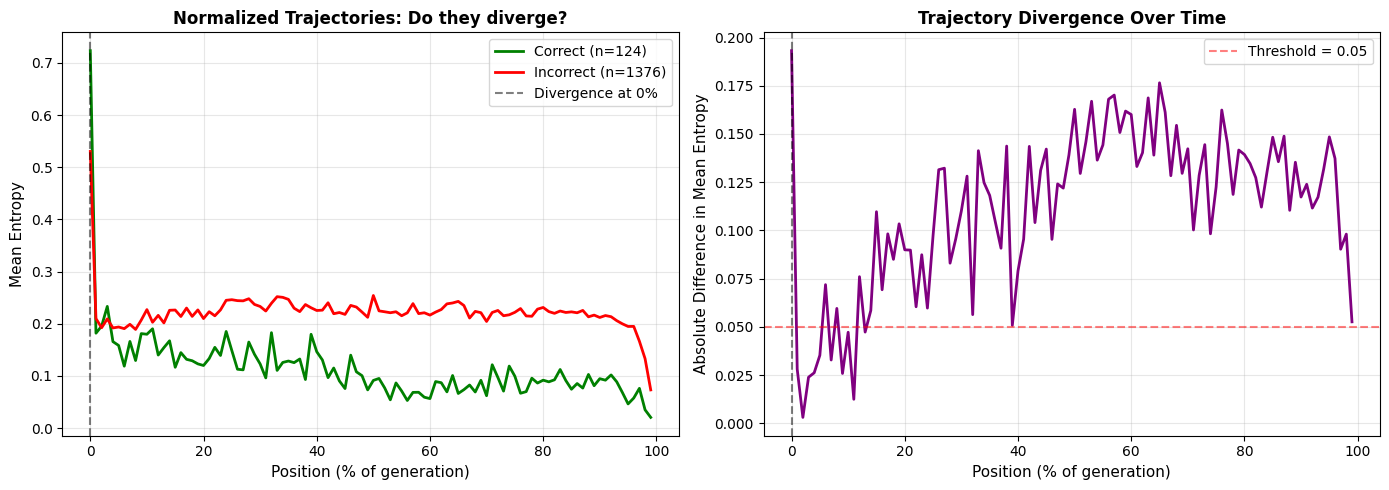


STATISTICAL ANALYSIS AT KEY POSITIONS (Mann-Whitney U)

POSITION 0%
Correct: μ=0.7235, σ=0.3548
Incorrect: μ=0.5303, σ=0.3228
Difference: 0.1932
U-statistic=112362.0, p=4.6545139990438776e-09

POSITION 5%
Correct: μ=0.1584, σ=0.3162
Incorrect: μ=0.1938, σ=0.3303
Difference: -0.0353
U-statistic=79218.0, p=0.18716684083547697

POSITION 20%
Correct: μ=0.1200, σ=0.2526
Incorrect: μ=0.2100, σ=0.3582
Difference: -0.0900
U-statistic=71606.0, p=0.0030100468481343828

POSITION 50%
Correct: μ=0.0914, σ=0.2107
Incorrect: μ=0.2541, σ=0.4459
Difference: -0.1628
U-statistic=60600.0, p=8.840106384435228e-08

POSITION 80%
Correct: μ=0.0919, σ=0.2116
Incorrect: μ=0.2312, σ=0.4336
Difference: -0.1394
U-statistic=61756.0, p=3.417166632097517e-07


In [7]:
# Same analysis but with Mann-Whitney U test instead of Welch's t-test
from scipy.stats import mannwhitneyu

# Use the same correct_seqs and incorrect_seqs from above
print("MANN-WHITNEY U TEST (Non-parametric)")
print("=" * 60)

# Same plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Trajectories (same as before)
ax1 = axes[0]
ax1.plot(positions, correct_traj, label=f'Correct (n={len(correct_seqs)})', 
         color='green', linewidth=2)
ax1.plot(positions, incorrect_traj, label=f'Incorrect (n={len(incorrect_seqs)})', 
         color='red', linewidth=2)
ax1.axvline(divergence_point, color='black', linestyle='--', alpha=0.5, 
            label=f'Divergence at {divergence_point}%')
ax1.set_xlabel('Position (% of generation)', fontsize=11)
ax1.set_ylabel('Mean Entropy', fontsize=11)
ax1.set_title('Normalized Trajectories: Do they diverge?', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Right plot: Difference over time (same as before)
ax2 = axes[1]
ax2.plot(positions, difference, color='purple', linewidth=2)
ax2.axhline(threshold, color='red', linestyle='--', alpha=0.5, 
            label=f'Threshold = {threshold}')
ax2.axvline(divergence_point, color='black', linestyle='--', alpha=0.5)
ax2.set_xlabel('Position (% of generation)', fontsize=11)
ax2.set_ylabel('Absolute Difference in Mean Entropy', fontsize=11)
ax2.set_title('Trajectory Divergence Over Time', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mann-Whitney U tests at key positions
print("\nSTATISTICAL ANALYSIS AT KEY POSITIONS (Mann-Whitney U)")
print("=" * 60)

for pct in [0, 5, 20, 50, 80]:
    print("\n" + "=" * 60)
    print(f"POSITION {pct}%")
    print("=" * 60)
    
    correct_vals = [seq[pct] for seq in correct_seqs]
    incorrect_vals = [seq[pct] for seq in incorrect_seqs]
    
    print(f"Correct: μ={np.mean(correct_vals):.4f}, σ={np.std(correct_vals):.4f}")
    print(f"Incorrect: μ={np.mean(incorrect_vals):.4f}, σ={np.std(incorrect_vals):.4f}")
    print(f"Difference: {np.mean(correct_vals) - np.mean(incorrect_vals):.4f}")
    
    # Mann-Whitney U test (two-sided)
    u_stat, p_val = mannwhitneyu(correct_vals, incorrect_vals, alternative='two-sided')
    
    print(f"U-statistic={u_stat:.1f}, p={p_val}")

Entropy Trajectories with Statistical Significance Regions


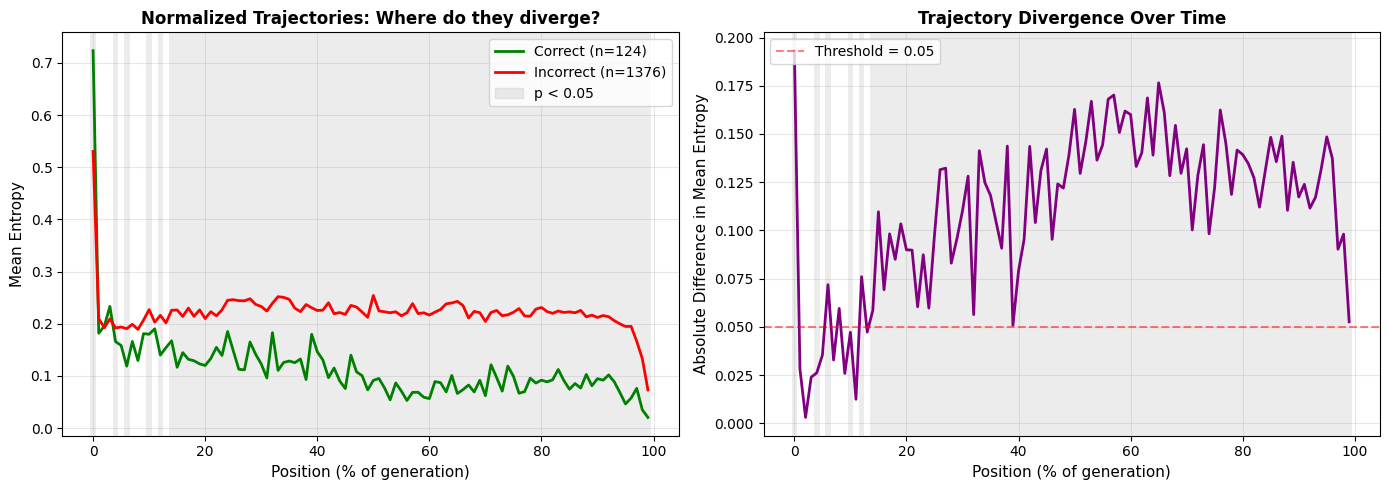


Significant positions (p < 0.05): 91/100 (91.0%)

Contiguous significant regions:
  0% - 0% (duration: 1%)
  4% - 4% (duration: 1%)
  6% - 6% (duration: 1%)
  10% - 10% (duration: 1%)
  12% - 12% (duration: 1%)
  14% - 99% (duration: 86%)


In [ ]:
# Same trajectories but with statistical significance shading
from scipy.stats import mannwhitneyu

print("Entropy Trajectories with Statistical Significance Regions")
print("=" * 60)

# Calculate p-values at every position
p_values = []
for pos in range(100):
    correct_vals = [seq[pos] for seq in correct_seqs]
    incorrect_vals = [seq[pos] for seq in incorrect_seqs]
    _, p_val = mannwhitneyu(correct_vals, incorrect_vals, alternative='two-sided')
    p_values.append(p_val)

p_values = np.array(p_values)

# Find regions of statistical significance (p < 0.05)
significant_mask = p_values < 0.05

# Create two-panel plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Trajectories with significance shading
ax1 = axes[0]
ax1.plot(positions, correct_traj, label=f'Correct (n={len(correct_seqs)})', 
         color='green', linewidth=2)
ax1.plot(positions, incorrect_traj, label=f'Incorrect (n={len(incorrect_seqs)})', 
         color='red', linewidth=2)

# Add shaded regions for statistical significance (no borders)
for i in range(len(positions)):
    if significant_mask[i]:
        ax1.axvspan(positions[i] - 0.5, positions[i] + 0.5, 
                    color='gray', alpha=0.15, linewidth=0, zorder=0)

# Add a patch to the legend for significance shading
from matplotlib.patches import Patch
significance_patch = Patch(color='gray', alpha=0.15, label='p < 0.05')

ax1.set_xlabel('Position (% of generation)', fontsize=11)
ax1.set_ylabel('Mean Entropy', fontsize=11)
ax1.set_title('Normalized Trajectories: Where do they diverge?', fontsize=12, fontweight='bold')
ax1.legend(handles=[*ax1.get_legend_handles_labels()[0], significance_patch], 
          fontsize=10, loc='upper right')
ax1.grid(True, alpha=0.3)

# Right plot: Difference over time
ax2 = axes[1]
ax2.plot(positions, difference, color='purple', linewidth=2)
ax2.axhline(threshold, color='red', linestyle='--', alpha=0.5, 
            label=f'Threshold = {threshold}')

# Add shaded regions for statistical significance (no borders)
for i in range(len(positions)):
    if significant_mask[i]:
        ax2.axvspan(positions[i] - 0.5, positions[i] + 0.5, 
                    color='gray', alpha=0.15, linewidth=0, zorder=0)

ax2.set_xlabel('Position (% of generation)', fontsize=11)
ax2.set_ylabel('Absolute Difference in Mean Entropy', fontsize=11)
ax2.set_title('Trajectory Divergence Over Time', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
n_significant = significant_mask.sum()
pct_significant = 100 * n_significant / len(positions)
print(f"\nSignificant positions (p < 0.05): {n_significant}/100 ({pct_significant:.1f}%)")

# Find contiguous regions of significance
sig_regions = []
in_region = False
start = None

for i in range(len(positions)):
    if significant_mask[i] and not in_region:
        start = i
        in_region = True
    elif not significant_mask[i] and in_region:
        sig_regions.append((start, i-1))
        in_region = False

if in_region:
    sig_regions.append((start, len(positions)-1))

print(f"\nContiguous significant regions:")
for start, end in sig_regions:
    print(f"  {start}% - {end}% (duration: {end-start+1}%)")

Computing normalized trajectories for both conditions...
Not Conditioned - Correct: 124, Incorrect: 1376
Conditioned - Correct: 1347, Incorrect: 153


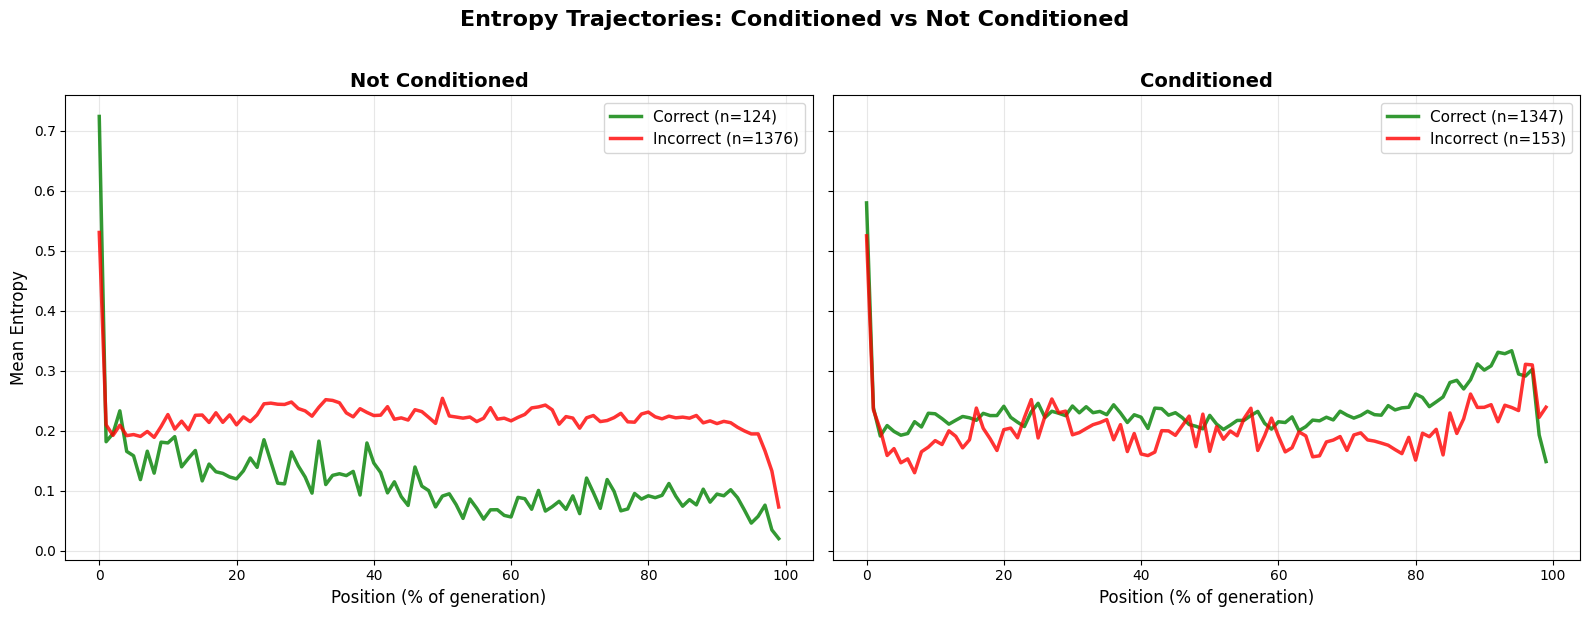


COMPARISON: NOT CONDITIONED vs CONDITIONED

Position 0%:
--------------------------------------------------------------------------------
NOT CONDITIONED:
  Correct: μ=0.7235, Incorrect: μ=0.5303
  Δ=0.1932
CONDITIONED:
  Correct: μ=0.5795, Incorrect: μ=0.5247
  Δ=0.0548
EFFECT REVERSAL: False (opposite signs = effect flips)

Position 20%:
--------------------------------------------------------------------------------
NOT CONDITIONED:
  Correct: μ=0.1200, Incorrect: μ=0.2100
  Δ=-0.0900
CONDITIONED:
  Correct: μ=0.2409, Incorrect: μ=0.2019
  Δ=0.0390
EFFECT REVERSAL: True (opposite signs = effect flips)

Position 50%:
--------------------------------------------------------------------------------
NOT CONDITIONED:
  Correct: μ=0.0914, Incorrect: μ=0.2541
  Δ=-0.1628
CONDITIONED:
  Correct: μ=0.2257, Incorrect: μ=0.1657
  Δ=0.0600
EFFECT REVERSAL: True (opposite signs = effect flips)

Position 80%:
--------------------------------------------------------------------------------
NOT CO

In [8]:
# Side-by-side comparison: Not Conditioned vs Conditioned
from scipy.interpolate import interp1d

# Get sequences for both conditions
print("Computing normalized trajectories for both conditions...")
print("="*60)

# Not conditioned (reuse from above)
nc_correct_traj = correct_traj
nc_incorrect_traj = incorrect_traj
nc_correct_seqs = correct_seqs
nc_incorrect_seqs = incorrect_seqs

# Conditioned (compute new)
c_correct_traj, c_incorrect_traj, c_correct_seqs, c_incorrect_seqs = normalize_and_compare(df, 'conditioned', target_len=100)

print(f"Not Conditioned - Correct: {len(nc_correct_seqs)}, Incorrect: {len(nc_incorrect_seqs)}")
print(f"Conditioned - Correct: {len(c_correct_seqs)}, Incorrect: {len(c_incorrect_seqs)}")

# Create side-by-side plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

positions = np.arange(100)

# Left panel: Not Conditioned
ax_nc = axes[0]
ax_nc.plot(positions, nc_correct_traj, label=f'Correct (n={len(nc_correct_seqs)})', 
          color='green', linewidth=2.5, alpha=0.8)
ax_nc.plot(positions, nc_incorrect_traj, label=f'Incorrect (n={len(nc_incorrect_seqs)})', 
          color='red', linewidth=2.5, alpha=0.8)
ax_nc.set_xlabel('Position (% of generation)', fontsize=12)
ax_nc.set_ylabel('Mean Entropy', fontsize=12)
ax_nc.set_title('Not Conditioned', fontsize=14, fontweight='bold')
ax_nc.legend(fontsize=11, loc='upper right')
ax_nc.grid(True, alpha=0.3)

# Right panel: Conditioned
ax_c = axes[1]
ax_c.plot(positions, c_correct_traj, label=f'Correct (n={len(c_correct_seqs)})', 
         color='green', linewidth=2.5, alpha=0.8)
ax_c.plot(positions, c_incorrect_traj, label=f'Incorrect (n={len(c_incorrect_seqs)})', 
         color='red', linewidth=2.5, alpha=0.8)
ax_c.set_xlabel('Position (% of generation)', fontsize=12)
ax_c.set_title('Conditioned', fontsize=14, fontweight='bold')
ax_c.legend(fontsize=11, loc='upper right')
ax_c.grid(True, alpha=0.3)

plt.suptitle('Entropy Trajectories: Conditioned vs Not Conditioned', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Compute statistics at key positions for both conditions
print("\n" + "="*80)
print("COMPARISON: NOT CONDITIONED vs CONDITIONED")
print("="*80)

for pct in [0, 20, 50, 80]:
    print(f"\nPosition {pct}%:")
    print("-"*80)
    
    # Not conditioned
    nc_correct_vals = [seq[pct] for seq in nc_correct_seqs]
    nc_incorrect_vals = [seq[pct] for seq in nc_incorrect_seqs]
    nc_diff = np.mean(nc_correct_vals) - np.mean(nc_incorrect_vals)
    
    # Conditioned
    c_correct_vals = [seq[pct] for seq in c_correct_seqs]
    c_incorrect_vals = [seq[pct] for seq in c_incorrect_seqs]
    c_diff = np.mean(c_correct_vals) - np.mean(c_incorrect_vals)
    
    print(f"NOT CONDITIONED:")
    print(f"  Correct: μ={np.mean(nc_correct_vals):.4f}, Incorrect: μ={np.mean(nc_incorrect_vals):.4f}")
    print(f"  Δ={nc_diff:.4f}")
    
    print(f"CONDITIONED:")
    print(f"  Correct: μ={np.mean(c_correct_vals):.4f}, Incorrect: μ={np.mean(c_incorrect_vals):.4f}")
    print(f"  Δ={c_diff:.4f}")
    
    print(f"EFFECT REVERSAL: {nc_diff * c_diff < 0} (opposite signs = effect flips)")

In [ ]:
# At 0% (very start)
print("=" * 60)
print("POSITION 0% (Start of Generation)")
print("=" * 60)
correct_start = [seq[0] for seq in correct_seqs]
incorrect_start = [seq[0] for seq in incorrect_seqs]

print(f"Correct: μ={np.mean(correct_start):.4f}, σ={np.std(correct_start):.4f}")
print(f"Incorrect: μ={np.mean(incorrect_start):.4f}, σ={np.std(incorrect_start):.4f}")
print(f"Difference: {np.mean(correct_start) - np.mean(incorrect_start):.4f}")

t_stat, p_val = stats.ttest_ind(correct_start, incorrect_start)
print(f"t={t_stat:.3f}, p={p_val:.6f}")

# At 5% (after initial exploration)
print("\n" + "=" * 60)
print("POSITION 5% (After Initial Exploration)")
print("=" * 60)
correct_5pct = [seq[5] for seq in correct_seqs]
incorrect_5pct = [seq[5] for seq in incorrect_seqs]

print(f"Correct: μ={np.mean(correct_5pct):.4f}, σ={np.std(correct_5pct):.4f}")
print(f"Incorrect: μ={np.mean(incorrect_5pct):.4f}, σ={np.std(incorrect_5pct):.4f}")
print(f"Difference: {np.mean(correct_5pct) - np.mean(incorrect_5pct):.4f}")

# At 20%, 50%, 80% as before
for pct in [20, 50, 80]:
    print("\n" + "=" * 60)
    print(f"POSITION {pct}%")
    print("=" * 60)
    correct_vals = [seq[pct] for seq in correct_seqs]
    incorrect_vals = [seq[pct] for seq in incorrect_seqs]
    
    print(f"Correct: μ={np.mean(correct_vals):.4f}, σ={np.std(correct_vals):.4f}")
    print(f"Incorrect: μ={np.mean(incorrect_vals):.4f}, σ={np.std(incorrect_vals):.4f}")
    print(f"Difference: {np.mean(correct_vals) - np.mean(incorrect_vals):.4f}")
    
    t_stat, p_val = stats.ttest_ind(correct_vals, incorrect_vals)
    pooled_std = np.sqrt(((len(correct_vals)-1)*np.std(correct_vals)**2 + 
                          (len(incorrect_vals)-1)*np.std(incorrect_vals)**2) / 
                         (len(correct_vals) + len(incorrect_vals) - 2))
    cohens_d = (np.mean(correct_vals) - np.mean(incorrect_vals)) / pooled_std
    
    print(f"t={t_stat:.3f}, p={p_val:.6f}, d={cohens_d:.3f}")

POSITION 0% (Start of Generation)
Correct: μ=0.7235, σ=0.3548
Incorrect: μ=0.5303, σ=0.3228
Difference: 0.1932
t=6.325, p=0.000000

POSITION 5% (After Initial Exploration)
Correct: μ=0.1584, σ=0.3162
Incorrect: μ=0.1938, σ=0.3303
Difference: -0.0353

POSITION 20%
Correct: μ=0.1200, σ=0.2526
Incorrect: μ=0.2100, σ=0.3582
Difference: -0.0900
t=-2.734, p=0.006321, d=-0.257

POSITION 50%
Correct: μ=0.0914, σ=0.2107
Incorrect: μ=0.2541, σ=0.4459
Difference: -0.1628
t=-4.022, p=0.000061, d=-0.377

POSITION 80%
Correct: μ=0.0919, σ=0.2116
Incorrect: μ=0.2312, σ=0.4336
Difference: -0.1394
t=-3.538, p=0.000415, d=-0.332



ENTROPY DROP ANALYSIS: Correct vs Incorrect

Initial Entropy:
  Correct: μ=0.7235, σ=0.3563
  Incorrect: μ=0.5303, σ=0.3229
  Difference: 0.1932
  t=6.325, p=0.000000, d=0.593

Entropy At 5Pct:
  Correct: μ=0.1584, σ=0.3175
  Incorrect: μ=0.1938, σ=0.3304
  Difference: -0.0353
  t=-1.144, p=0.252743, d=-0.107

Entropy At 20Pct:
  Correct: μ=0.1200, σ=0.2536
  Incorrect: μ=0.2100, σ=0.3584
  Difference: -0.0900
  t=-2.734, p=0.006321, d=-0.256

Drop 0 To 5:
  Correct: μ=0.5651, σ=0.5203
  Incorrect: μ=0.3365, σ=0.4767
  Difference: 0.2285
  t=5.073, p=0.000000, d=0.476

Drop 0 To 20:
  Correct: μ=0.6035, σ=0.4902
  Incorrect: μ=0.3204, σ=0.4959
  Difference: 0.2832
  t=6.096, p=0.000000, d=0.572

Drop 5 To 20:
  Correct: μ=0.0385, σ=0.3562
  Incorrect: μ=-0.0162, σ=0.4808
  Difference: 0.0546
  t=1.235, p=0.216944, d=0.116


/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/911354950.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([correct_data, incorrect_data],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/911354950.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([correct_data, incorrect_data],
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_44074/911354950.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([correct_data, incorrect_data],


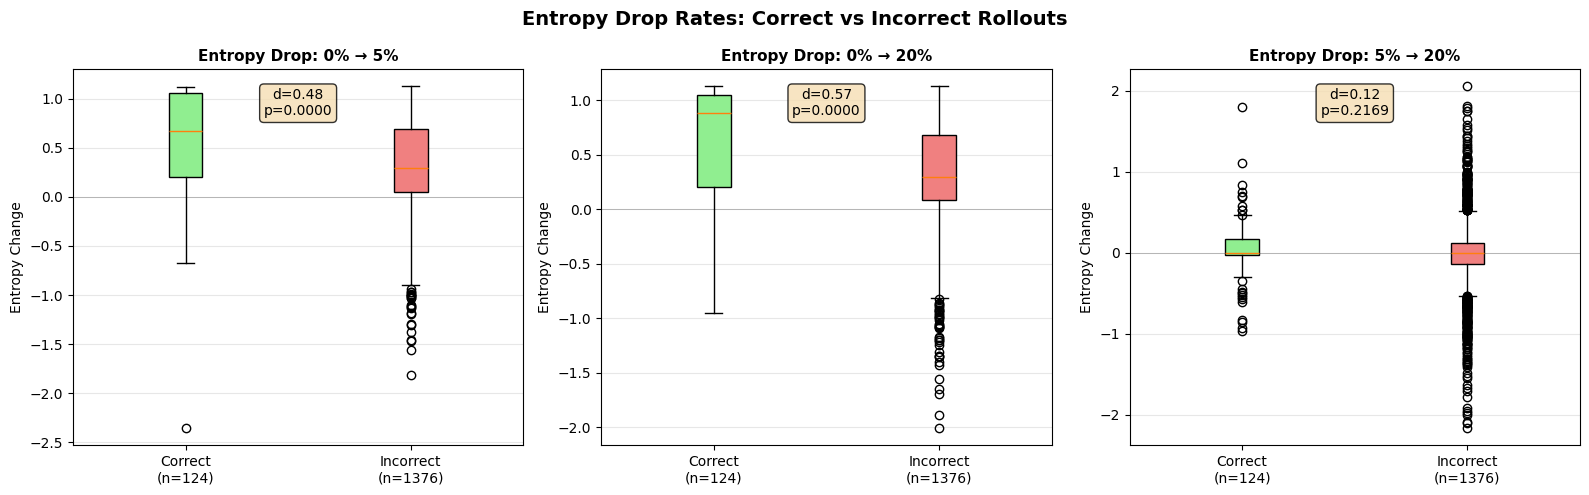

In [ ]:
# Compute entropy drop for each rollout
df_nc = df[df['condition'] == 'not_conditioned']

entropy_drops = []

for _, row in df_nc.iterrows():
    try:
        # Load full entropy sequence
        with open(f'experiments/{row["experiment"]}/problem_{row["problem_idx"]}/rollout_{row["rollout_idx"]}/graph_structure.json', 'r') as f:
            graph = json.load(f)
        entropy_seq = np.array([item['metric_value'] for item in graph['final_sequence']])
        
        # Normalize to 100 points
        if len(entropy_seq) < 2:
            continue
            
        x_old = np.linspace(0, 1, len(entropy_seq))
        x_new = np.linspace(0, 1, 100)
        f = interp1d(x_old, entropy_seq, kind='linear')
        normalized_seq = f(x_new)
        
        # Compute drops at different intervals
        drop_0_to_5 = normalized_seq[0] - normalized_seq[5]
        drop_0_to_20 = normalized_seq[0] - normalized_seq[20]
        drop_5_to_20 = normalized_seq[5] - normalized_seq[20]
        
        entropy_drops.append({
            'is_correct': row['is_correct'],
            'initial_entropy': normalized_seq[0],
            'entropy_at_5pct': normalized_seq[5],
            'entropy_at_20pct': normalized_seq[20],
            'drop_0_to_5': drop_0_to_5,
            'drop_0_to_20': drop_0_to_20,
            'drop_5_to_20': drop_5_to_20
        })
    except (FileNotFoundError, KeyError, ValueError):
        continue

df_drops = pd.DataFrame(entropy_drops)

# Compare drops between correct and incorrect
print("\n" + "=" * 70)
print("ENTROPY DROP ANALYSIS: Correct vs Incorrect")
print("=" * 70)

metrics = ['initial_entropy', 'entropy_at_5pct', 'entropy_at_20pct', 
           'drop_0_to_5', 'drop_0_to_20', 'drop_5_to_20']

for metric in metrics:
    correct_vals = df_drops[df_drops['is_correct']][metric]
    incorrect_vals = df_drops[~df_drops['is_correct']][metric]
    
    t_stat, p_val = stats.ttest_ind(correct_vals, incorrect_vals)
    pooled_std = np.sqrt(((len(correct_vals)-1)*correct_vals.std()**2 + 
                          (len(incorrect_vals)-1)*incorrect_vals.std()**2) / 
                         (len(correct_vals) + len(incorrect_vals) - 2))
    cohens_d = (correct_vals.mean() - incorrect_vals.mean()) / pooled_std
    
    print(f"\n{metric.replace('_', ' ').title()}:")
    print(f"  Correct: μ={correct_vals.mean():.4f}, σ={correct_vals.std():.4f}")
    print(f"  Incorrect: μ={incorrect_vals.mean():.4f}, σ={incorrect_vals.std():.4f}")
    print(f"  Difference: {correct_vals.mean() - incorrect_vals.mean():.4f}")
    print(f"  t={t_stat:.3f}, p={p_val:.6f}, d={cohens_d:.3f}")

# Visualization of drops
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

drop_metrics = ['drop_0_to_5', 'drop_0_to_20', 'drop_5_to_20']
titles = ['Entropy Drop: 0% → 5%', 'Entropy Drop: 0% → 20%', 'Entropy Drop: 5% → 20%']

for idx, (metric, title) in enumerate(zip(drop_metrics, titles)):
    ax = axes[idx]
    
    correct_data = df_drops[df_drops['is_correct']][metric]
    incorrect_data = df_drops[~df_drops['is_correct']][metric]
    
    bp = ax.boxplot([correct_data, incorrect_data],
                     labels=[f'Correct\n(n={len(correct_data)})', 
                            f'Incorrect\n(n={len(incorrect_data)})'],
                     patch_artist=True)
    
    bp['boxes'][0].set_facecolor('lightgreen')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    # Add statistics annotation
    t_stat, p_val = stats.ttest_ind(correct_data, incorrect_data)
    pooled_std = np.sqrt(((len(correct_data)-1)*correct_data.std()**2 + 
                          (len(incorrect_data)-1)*incorrect_data.std()**2) / 
                         (len(correct_data) + len(incorrect_data) - 2))
    cohens_d = (correct_data.mean() - incorrect_data.mean()) / pooled_std
    
    ax.text(0.5, 0.95, f"d={cohens_d:.2f}\np={p_val:.4f}",
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
            fontsize=10)
    
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Entropy Change', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)

plt.suptitle('Entropy Drop Rates: Correct vs Incorrect Rollouts', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## With Backtracking

Correct paths: 270
Incorrect paths: 703


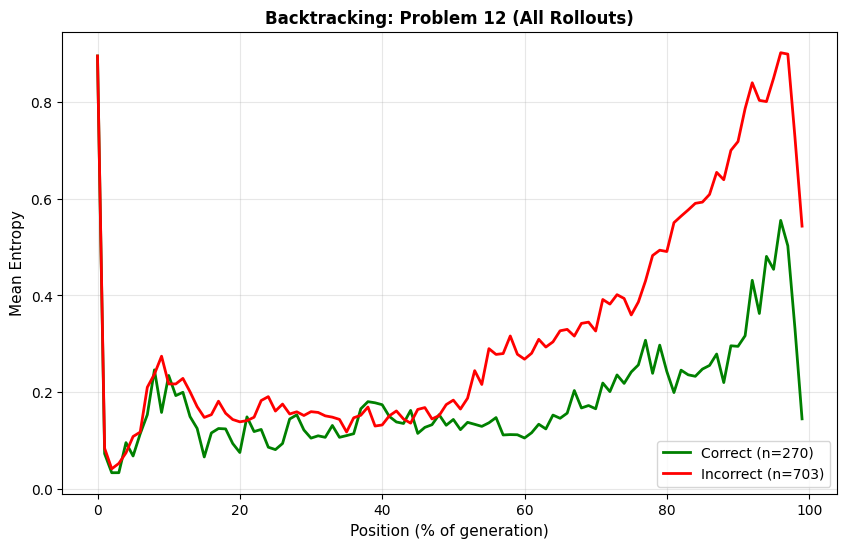


Position 0%:
  Correct: μ=0.8945, σ=0.0000
  Incorrect: μ=0.8945, σ=0.0000
  Δ=0.0000
  t=nan, p=nan, d=nan

Position 20%:
  Correct: μ=0.0755, σ=0.1911
  Incorrect: μ=0.1389, σ=0.3378
  Δ=-0.0634
  t=-2.906, p=0.0037391494314705596, d=-0.208

Position 50%:
  Correct: μ=0.1437, σ=0.3306
  Incorrect: μ=0.1837, σ=0.3598
  Δ=-0.0400
  t=-1.585, p=0.1133388072877375, d=-0.114

Position 80%:
  Correct: μ=0.2428, σ=0.4876
  Incorrect: μ=0.4907, σ=0.7580
  Δ=-0.2479
  t=-4.986, p=7.288226098669306e-07, d=-0.357


/Users/adityashukzy/Documents/GitHub/MAT1510-Project/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/var/folders/6b/6g1xv5sn2cs9wwpffpgn0l080000gn/T/ipykernel_71413/1576061809.py:64: RuntimeWarning: invalid value encountered in scalar divide
  cohens_d = (np.mean(correct_vals) - np.mean(incorrect_vals)) / pooled_std


In [8]:
# Load backtracking paths and analyze - ALL ROLLOUTS for problem 12
paths_json_path = 'experiments/aime_full_20251120_162143/paths.json'
problem_idx = 12

with open(paths_json_path, 'r') as f:
    all_paths = json.load(f)

# Aggregate across all rollouts for this problem
correct_seqs = []
incorrect_seqs = []

problem_data = all_paths[str(problem_idx)]

for rollout_idx_str, paths in problem_data.items():
    for path in paths:
        entropy_seq = np.array([entropy for token, entropy in path['tokens_with_entropy']])
        
        if len(entropy_seq) < 2:
            continue
        
        # Normalize to 100 points
        x_old = np.linspace(0, 1, len(entropy_seq))
        x_new = np.linspace(0, 1, 100)
        f = interp1d(x_old, entropy_seq, kind='linear')
        normalized = f(x_new)
        
        if path['is_correct']:
            correct_seqs.append(normalized)
        else:
            incorrect_seqs.append(normalized)

# Compute mean trajectories
correct_mean = np.mean(correct_seqs, axis=0)
incorrect_mean = np.mean(incorrect_seqs, axis=0)

print(f"Correct paths: {len(correct_seqs)}")
print(f"Incorrect paths: {len(incorrect_seqs)}")

# Plot
positions = np.arange(100)

plt.figure(figsize=(10, 6))
plt.plot(positions, correct_mean, label=f'Correct (n={len(correct_seqs)})', 
         color='green', linewidth=2)
plt.plot(positions, incorrect_mean, label=f'Incorrect (n={len(incorrect_seqs)})', 
         color='red', linewidth=2)
plt.xlabel('Position (% of generation)', fontsize=11)
plt.ylabel('Mean Entropy', fontsize=11)
plt.title(f'Backtracking: Problem {problem_idx} (All Rollouts)', 
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# T-test at key positions
for pct in [0, 20, 50, 80]:
    correct_vals = [seq[pct] for seq in correct_seqs]
    incorrect_vals = [seq[pct] for seq in incorrect_seqs]
    
    t_stat, p_val = stats.ttest_ind(correct_vals, incorrect_vals)
    pooled_std = np.sqrt(((len(correct_vals)-1)*np.std(correct_vals)**2 + 
                          (len(incorrect_vals)-1)*np.std(incorrect_vals)**2) / 
                         (len(correct_vals) + len(incorrect_vals) - 2))
    cohens_d = (np.mean(correct_vals) - np.mean(incorrect_vals)) / pooled_std
    
    print(f"\nPosition {pct}%:")
    print(f"  Correct: μ={np.mean(correct_vals):.4f}, σ={np.std(correct_vals):.4f}")
    print(f"  Incorrect: μ={np.mean(incorrect_vals):.4f}, σ={np.std(incorrect_vals):.4f}")
    print(f"  Δ={np.mean(correct_vals) - np.mean(incorrect_vals):.4f}")
    print(f"  t={t_stat:.3f}, p={p_val}, d={cohens_d:.3f}")

BACKTRACKING: Mann-Whitney U Test (Problem 12)
Correct paths: 270
Incorrect paths: 703

Expected U under null (no difference): 94905.0


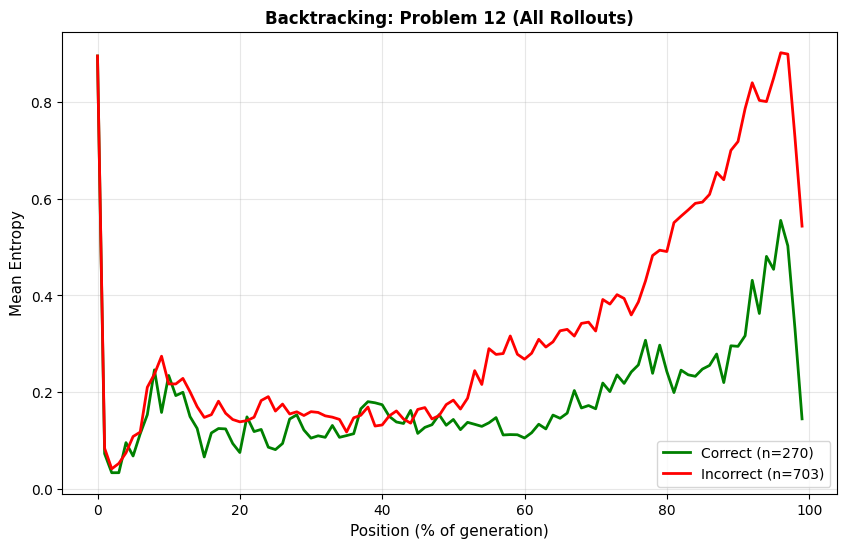


STATISTICAL TESTS (Mann-Whitney U)

Position 0%:
  Correct: μ=0.8945, σ=0.0000
  Incorrect: μ=0.8945, σ=0.0000
  Δ=0.0000
  U=94905.0 (expected=94905.0), p=1.0

Position 20%:
  Correct: μ=0.0755, σ=0.1911
  Incorrect: μ=0.1389, σ=0.3378
  Δ=-0.0634
  U=84693.0 (expected=94905.0), p=0.00927871759384591

Position 50%:
  Correct: μ=0.1437, σ=0.3306
  Incorrect: μ=0.1837, σ=0.3598
  Δ=-0.0400
  U=82694.5 (expected=94905.0), p=0.001865981577508375

Position 80%:
  Correct: μ=0.2428, σ=0.4876
  Incorrect: μ=0.4907, σ=0.7580
  Δ=-0.2479
  U=70617.5 (expected=94905.0), p=6.106322590257082e-10


In [9]:
# Backtracking: Mann-Whitney U test
from scipy.stats import mannwhitneyu

# Reuse correct_seqs and incorrect_seqs from above (backtracking paths)
print("BACKTRACKING: Mann-Whitney U Test (Problem 12)")
print("="*60)
print(f"Correct paths: {len(correct_seqs)}")
print(f"Incorrect paths: {len(incorrect_seqs)}")

# Expected U under null hypothesis
n1 = len(correct_seqs)
n2 = len(incorrect_seqs)
expected_u = (n1 * n2) / 2
print(f"\nExpected U under null (no difference): {expected_u:.1f}")

# Plot (same as before)
positions = np.arange(100)

plt.figure(figsize=(10, 6))
plt.plot(positions, correct_mean, label=f'Correct (n={len(correct_seqs)})', 
         color='green', linewidth=2)
plt.plot(positions, incorrect_mean, label=f'Incorrect (n={len(incorrect_seqs)})', 
         color='red', linewidth=2)
plt.xlabel('Position (% of generation)', fontsize=11)
plt.ylabel('Mean Entropy', fontsize=11)
plt.title(f'Backtracking: Problem {problem_idx} (All Rollouts)', 
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Mann-Whitney U tests at key positions
print("\n" + "="*60)
print("STATISTICAL TESTS (Mann-Whitney U)")
print("="*60)

for pct in [0, 20, 50, 80]:
    correct_vals = [seq[pct] for seq in correct_seqs]
    incorrect_vals = [seq[pct] for seq in incorrect_seqs]
    
    u_stat, p_val = mannwhitneyu(correct_vals, incorrect_vals, alternative='two-sided')
    
    print(f"\nPosition {pct}%:")
    print(f"  Correct: μ={np.mean(correct_vals):.4f}, σ={np.std(correct_vals):.4f}")
    print(f"  Incorrect: μ={np.mean(incorrect_vals):.4f}, σ={np.std(incorrect_vals):.4f}")
    print(f"  Δ={np.mean(correct_vals) - np.mean(incorrect_vals):.4f}")
    print(f"  U={u_stat:.1f} (expected={expected_u:.1f}), p={p_val}")

## Single Pass again (but only for hand-picked problems)

In [ ]:
df_handpicked[(df_handpicked['problem_idx'] == 0) & (df_handpicked['condition'] == 'not_conditioned')]

,experiment,condition,problem_idx,rollout_idx,is_correct,num_tokens,mean_entropy,median_entropy,std_entropy,num_spikes,phase_shifts,max_entropy,late_stage_mean,cumulative_normalized
0,aim_1_20251113_025853,not_conditioned,0,0,True,1031,0.073540,0.000018,0.226627,20,137,1.859375,0.067520,0.073540
1,aim_1_20251113_025853,not_conditioned,0,1,False,1139,0.098681,0.000126,0.250649,21,154,1.835938,0.098725,0.098681
2,aim_1_20251113_025853,not_conditioned,0,2,False,1220,0.083792,0.000028,0.234245,24,160,2.140625,0.129111,0.083792
3,aim_1_20251113_025853,not_conditioned,0,3,True,1071,0.066520,0.000021,0.202809,22,141,1.445312,0.069744,0.066520
4,aim_1_20251113_025853,not_conditioned,0,4,False,1584,0.095532,0.000062,0.262420,30,215,1.898438,0.160986,0.095532
5,aim_1_20251113_025853,not_conditioned,0,5,False,1530,0.124799,0.000103,0.307298,30,207,2.156250,0.186992,0.124799
6,aim_1_20251113_025853,not_conditioned,0,6,True,1219,0.091497,0.000024,0.261009,27,163,1.835938,0.148038,0.091497
7,aim_1_20251113_025853,not_conditioned,0,7,False,1162,0.141688,0.002159,0.306779,23,161,2.218750,0.206400,0.141688
8,aim_1_20251113_025853,not_conditioned,0,8,False,1044,0.079294,0.000034,0.227321,21,140,1.867188,0.082843,0.079294
9,aim_1_20251113_025853,not_conditioned,0,9,True,1187,0.076706,0.000035,0.218385,22,158,1.617188,0.111650,0.076706


Handpicked problems: [0, 9, 12]
Total rollouts in handpicked set: 300
Correct: 209, Incorrect: 91

Accuracy per problem:
  Problem 0: 22/50 = 44.0%
  Problem 9: 26/50 = 52.0%
  Problem 12: 18/50 = 36.0%

Correct sequences: 66
Incorrect sequences: 84


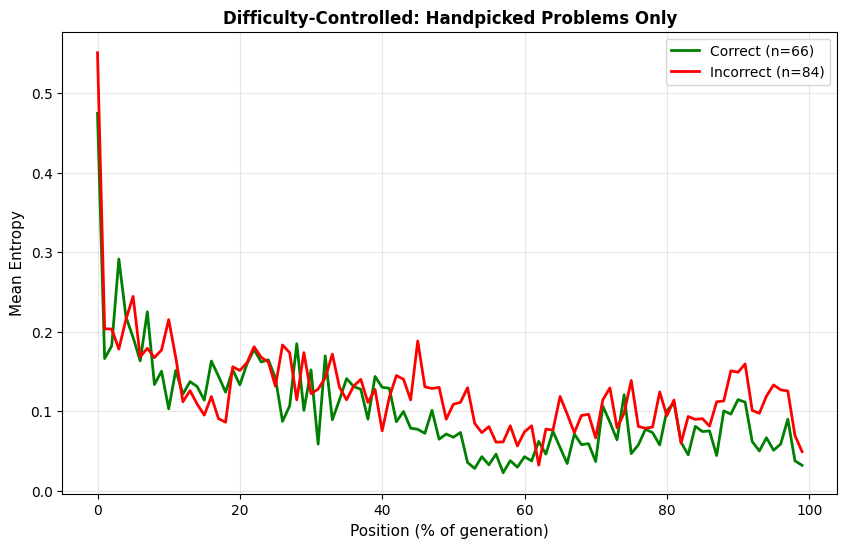


STATISTICAL TESTS (Difficulty-Controlled)

Position 0%:
  Correct: μ=0.4748, σ=0.2843
  Incorrect: μ=0.5512, σ=0.2960
  Δ=-0.0763
  t=-1.584, p=0.115323, d=-0.262

Position 20%:
  Correct: μ=0.1331, σ=0.2289
  Incorrect: μ=0.1511, σ=0.2792
  Δ=-0.0181
  t=-0.422, p=0.673342, d=-0.070

Position 50%:
  Correct: μ=0.0671, σ=0.1439
  Incorrect: μ=0.1086, σ=0.2550
  Δ=-0.0415
  t=-1.174, p=0.242122, d=-0.194

Position 80%:
  Correct: μ=0.1004, σ=0.2422
  Incorrect: μ=0.0941, σ=0.2571
  Δ=0.0063
  t=0.153, p=0.878950, d=0.025


In [11]:
# Filter to handpicked problems only (difficulty-controlled)
# handpicked_problems = [0, 1, 6, 12, 22, 25]
handpicked_problems = [0, 9, 12]
df_handpicked = df[df['problem_idx'].isin(handpicked_problems)]

print(f"Handpicked problems: {handpicked_problems}")
print(f"Total rollouts in handpicked set: {len(df_handpicked)}")
print(f"Correct: {df_handpicked['is_correct'].sum()}, Incorrect: {(~df_handpicked['is_correct']).sum()}")

# Check accuracy per problem to verify similar difficulty
print("\nAccuracy per problem:")
for prob in handpicked_problems:
    prob_df = df_handpicked[(df_handpicked['problem_idx'] == prob) & (df_handpicked['condition'] == 'not_conditioned')]
    if len(prob_df) > 0:
        acc = 100 * prob_df['is_correct'].sum() / len(prob_df)
        print(f"  Problem {prob}: {prob_df['is_correct'].sum()}/{len(prob_df)} = {acc:.1f}%")

# Run normalized trajectory analysis on handpicked problems
df_handpicked_nc = df_handpicked[df_handpicked['condition'] == 'not_conditioned']

correct_seqs_hp = []
incorrect_seqs_hp = []

for _, row in df_handpicked_nc.iterrows():
    try:
        with open(f'experiments/{row["experiment"]}/problem_{row["problem_idx"]}/rollout_{row["rollout_idx"]}/graph_structure.json', 'r') as f:
            graph = json.load(f)
        entropy_seq = np.array([item['metric_value'] for item in graph['final_sequence']])
        
        if len(entropy_seq) < 2:
            continue
            
        x_old = np.linspace(0, 1, len(entropy_seq))
        x_new = np.linspace(0, 1, 100)
        f = interp1d(x_old, entropy_seq, kind='linear')
        normalized = f(x_new)
        
        if row['is_correct']:
            correct_seqs_hp.append(normalized)
        else:
            incorrect_seqs_hp.append(normalized)
    except (FileNotFoundError, KeyError, ValueError):
        continue

correct_mean_hp = np.mean(correct_seqs_hp, axis=0)
incorrect_mean_hp = np.mean(incorrect_seqs_hp, axis=0)

print(f"\nCorrect sequences: {len(correct_seqs_hp)}")
print(f"Incorrect sequences: {len(incorrect_seqs_hp)}")

# Plot
positions = np.arange(100)

plt.figure(figsize=(10, 6))
plt.plot(positions, correct_mean_hp, label=f'Correct (n={len(correct_seqs_hp)})', 
         color='green', linewidth=2)
plt.plot(positions, incorrect_mean_hp, label=f'Incorrect (n={len(incorrect_seqs_hp)})', 
         color='red', linewidth=2)
plt.xlabel('Position (% of generation)', fontsize=11)
plt.ylabel('Mean Entropy', fontsize=11)
plt.title('Difficulty-Controlled: Handpicked Problems Only', 
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# T-test at key positions
print("\n" + "="*60)
print("STATISTICAL TESTS (Difficulty-Controlled)")
print("="*60)

for pct in [0, 20, 50, 80]:
    correct_vals = [seq[pct] for seq in correct_seqs_hp]
    incorrect_vals = [seq[pct] for seq in incorrect_seqs_hp]
    
    t_stat, p_val = stats.ttest_ind(correct_vals, incorrect_vals)
    pooled_std = np.sqrt(((len(correct_vals)-1)*np.std(correct_vals)**2 + 
                          (len(incorrect_vals)-1)*np.std(incorrect_vals)**2) / 
                         (len(correct_vals) + len(incorrect_vals) - 2))
    cohens_d = (np.mean(correct_vals) - np.mean(incorrect_vals)) / pooled_std
    
    print(f"\nPosition {pct}%:")
    print(f"  Correct: μ={np.mean(correct_vals):.4f}, σ={np.std(correct_vals):.4f}")
    print(f"  Incorrect: μ={np.mean(incorrect_vals):.4f}, σ={np.std(incorrect_vals):.4f}")
    print(f"  Δ={np.mean(correct_vals) - np.mean(incorrect_vals):.4f}")
    print(f"  t={t_stat:.3f}, p={p_val:.6f}, d={cohens_d:.3f}")

DIFFICULTY-CONTROLLED: Mann-Whitney U Test
Problems: [0, 9, 12]
Correct sequences: 66
Incorrect sequences: 84

Expected U under null (no difference): 2772.0


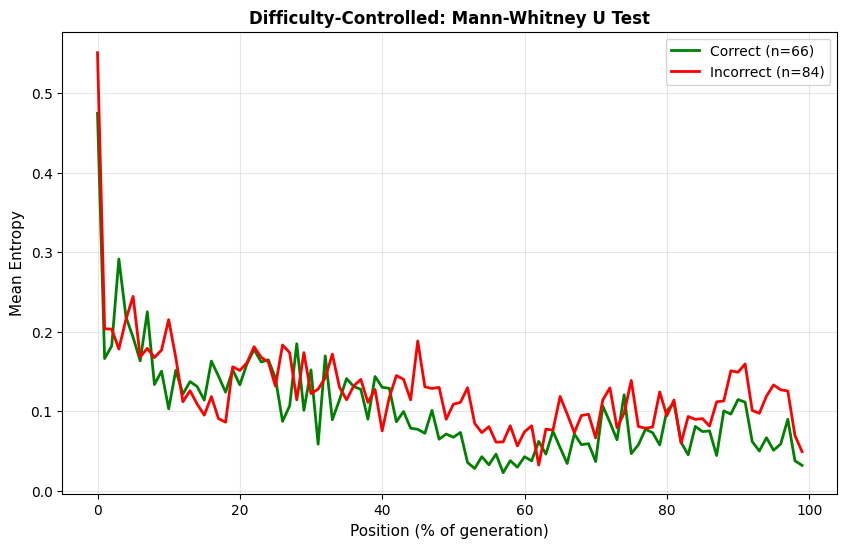


STATISTICAL TESTS (Mann-Whitney U)

Position 0%:
  Correct: μ=0.4748, σ=0.2843
  Incorrect: μ=0.5512, σ=0.2960
  Δ=-0.0763
  U=2372.0 (expected=2772.0), p=0.108657

Position 20%:
  Correct: μ=0.1331, σ=0.2289
  Incorrect: μ=0.1511, σ=0.2792
  Δ=-0.0181
  U=2902.0 (expected=2772.0), p=0.623923

Position 50%:
  Correct: μ=0.0671, σ=0.1439
  Incorrect: μ=0.1086, σ=0.2550
  Δ=-0.0415
  U=2482.0 (expected=2772.0), p=0.273047

Position 80%:
  Correct: μ=0.1004, σ=0.2422
  Incorrect: μ=0.0941, σ=0.2571
  Δ=0.0063
  U=2687.0 (expected=2772.0), p=0.749026


In [12]:
# Difficulty-controlled analysis with Mann-Whitney U test
from scipy.stats import mannwhitneyu

handpicked_problems = [0, 9, 12]
df_handpicked = df[df['problem_idx'].isin(handpicked_problems)]
df_handpicked_nc = df_handpicked[df_handpicked['condition'] == 'not_conditioned']

# Reuse sequences from above (already computed)
# correct_seqs_hp and incorrect_seqs_hp

print("DIFFICULTY-CONTROLLED: Mann-Whitney U Test")
print("="*60)
print(f"Problems: {handpicked_problems}")
print(f"Correct sequences: {len(correct_seqs_hp)}")
print(f"Incorrect sequences: {len(incorrect_seqs_hp)}")

# Expected U under null hypothesis
n1 = len(correct_seqs_hp)
n2 = len(incorrect_seqs_hp)
expected_u = (n1 * n2) / 2
print(f"\nExpected U under null (no difference): {expected_u:.1f}")

# Plot (same as before)
positions = np.arange(100)

plt.figure(figsize=(10, 6))
plt.plot(positions, correct_mean_hp, label=f'Correct (n={len(correct_seqs_hp)})', 
         color='green', linewidth=2)
plt.plot(positions, incorrect_mean_hp, label=f'Incorrect (n={len(incorrect_seqs_hp)})', 
         color='red', linewidth=2)
plt.xlabel('Position (% of generation)', fontsize=11)
plt.ylabel('Mean Entropy', fontsize=11)
plt.title('Difficulty-Controlled: Mann-Whitney U Test', 
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Mann-Whitney U tests
print("\n" + "="*60)
print("STATISTICAL TESTS (Mann-Whitney U)")
print("="*60)

for pct in [0, 20, 50, 80]:
    correct_vals = [seq[pct] for seq in correct_seqs_hp]
    incorrect_vals = [seq[pct] for seq in incorrect_seqs_hp]
    
    u_stat, p_val = mannwhitneyu(correct_vals, incorrect_vals, alternative='two-sided')
    
    print(f"\nPosition {pct}%:")
    print(f"  Correct: μ={np.mean(correct_vals):.4f}, σ={np.std(correct_vals):.4f}")
    print(f"  Incorrect: μ={np.mean(incorrect_vals):.4f}, σ={np.std(incorrect_vals):.4f}")
    print(f"  Δ={np.mean(correct_vals) - np.mean(incorrect_vals):.4f}")
    print(f"  U={u_stat:.1f} (expected={expected_u:.1f}), p={p_val:.6f}")

In [17]:
# Show accuracy across all 30 problems to identify difficulty-controlled subset
df_nc_all = df[df['condition'] == 'not_conditioned']

print("Accuracy per problem across all 30 AIME problems:")
print("="*60)

problem_stats = []
for prob in range(30):
    prob_df = df_nc_all[df_nc_all['problem_idx'] == prob]
    if len(prob_df) > 0:
        n_correct = prob_df['is_correct'].sum()
        n_total = len(prob_df)
        acc = 100 * n_correct / n_total
        problem_stats.append({
            'problem': prob,
            'correct': n_correct,
            'total': n_total,
            'accuracy': acc
        })
        print(f"  Problem {prob:2d}: {n_correct:2d}/{n_total:2d} = {acc:5.1f}%")

# Convert to dataframe and sort by accuracy
df_prob_stats = pd.DataFrame(problem_stats)
df_prob_stats_sorted = df_prob_stats.sort_values('accuracy', ascending=False)

print("\n" + "="*60)
print("Sorted by accuracy (easiest to hardest):")
print("="*60)
for _, row in df_prob_stats_sorted.iterrows():
    print(f"  Problem {int(row['problem']):2d}: {int(row['correct']):2d}/{int(row['total']):2d} = {row['accuracy']:5.1f}%")

print("\n" + "="*60)
print("Suggested subset (20-50% accuracy range):")
print("="*60)
suggested = df_prob_stats_sorted[(df_prob_stats_sorted['accuracy'] >= 20) & 
                                  (df_prob_stats_sorted['accuracy'] <= 50)]
print(f"Problems: {sorted(suggested['problem'].astype(int).tolist())}")
print(f"Total rollouts: {suggested['total'].sum()}")
print(f"Overall accuracy: {100*suggested['correct'].sum()/suggested['total'].sum():.1f}%")

Accuracy per problem across all 30 AIME problems:
  Problem  0: 22/50 =  44.0%
  Problem  1:  0/50 =   0.0%
  Problem  2:  0/50 =   0.0%
  Problem  3:  0/50 =   0.0%
  Problem  4:  0/50 =   0.0%
  Problem  5:  0/50 =   0.0%
  Problem  6:  0/50 =   0.0%
  Problem  7: 40/50 =  80.0%
  Problem  8:  1/50 =   2.0%
  Problem  9: 26/50 =  52.0%
  Problem 10:  0/50 =   0.0%
  Problem 11:  0/50 =   0.0%
  Problem 12: 18/50 =  36.0%
  Problem 13:  0/50 =   0.0%
  Problem 14:  2/50 =   4.0%
  Problem 15:  0/50 =   0.0%
  Problem 16:  0/50 =   0.0%
  Problem 17:  0/50 =   0.0%
  Problem 18:  2/50 =   4.0%
  Problem 19:  0/50 =   0.0%
  Problem 20:  0/50 =   0.0%
  Problem 21:  0/50 =   0.0%
  Problem 22:  1/50 =   2.0%
  Problem 23:  0/50 =   0.0%
  Problem 24:  5/50 =  10.0%
  Problem 25:  5/50 =  10.0%
  Problem 26:  2/50 =   4.0%
  Problem 27:  0/50 =   0.0%
  Problem 28:  0/50 =   0.0%
  Problem 29:  0/50 =   0.0%

Sorted by accuracy (easiest to hardest):
  Problem  7: 40/50 =  80.0%
  Problem

# Appendix

In [ ]:
from scipy.interpolate import interp1d

def normalize_sequence(entropy_seq, target_length=500):
    """Interpolate sequence to fixed length."""
    if len(entropy_seq) < 2:
        return np.full(target_length, np.nan)
    
    x_old = np.linspace(0, 1, len(entropy_seq))
    x_new = np.linspace(0, 1, target_length)
    f = interp1d(x_old, entropy_seq, kind='linear')
    return f(x_new)

# Then in your plotting function:
sequences_normalized = [normalize_sequence(seq) for seq in sequences]
means = np.mean(sequences_normalized, axis=0)
stds = np.std(sequences_normalized, axis=0)

In [ ]:
np.linspace(0, 1, 5), np.linspace(0, 1, 10)

(array([0.  , 0.25, 0.5 , 0.75, 1.  ]),
 array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
        0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]))

In [ ]:
f = interp1d(np.linspace(0, 1, 5), [1, 2, 3, 4, 5], kind='linear')
f(np.linspace(0, 1, 20))

array([1.        , 1.21052632, 1.42105263, 1.63157895, 1.84210526,
       2.05263158, 2.26315789, 2.47368421, 2.68421053, 2.89473684,
       3.10526316, 3.31578947, 3.52631579, 3.73684211, 3.94736842,
       4.15789474, 4.36842105, 4.57894737, 4.78947368, 5.        ])